#Market Regimes & Adaptive Portfolio Construction


importing modules and retrieving data

In [ ]:
!pip install hmmlearn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

df = pd.read_csv('wsc excel.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


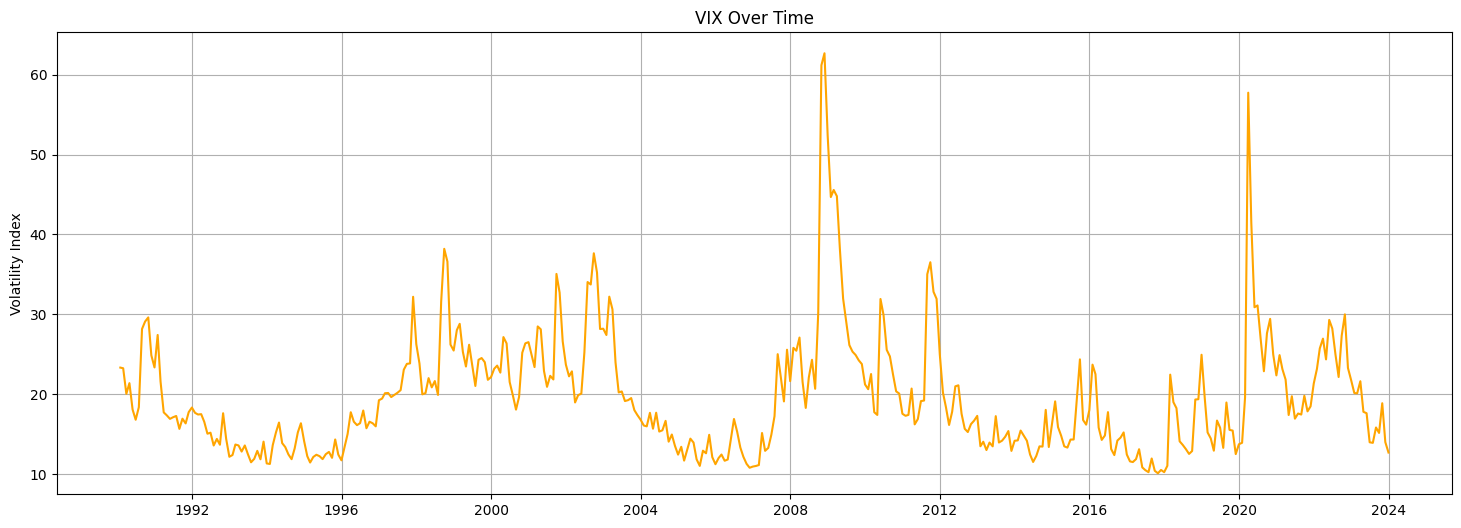

In [ ]:
# Plotting VIX over Time
plt.figure(figsize=(18,6))
plt.plot(df['VIX'], color='orange')
plt.title('VIX Over Time')
plt.ylabel('Volatility Index')
plt.grid(True)
plt.show()

Equity Curve Graph

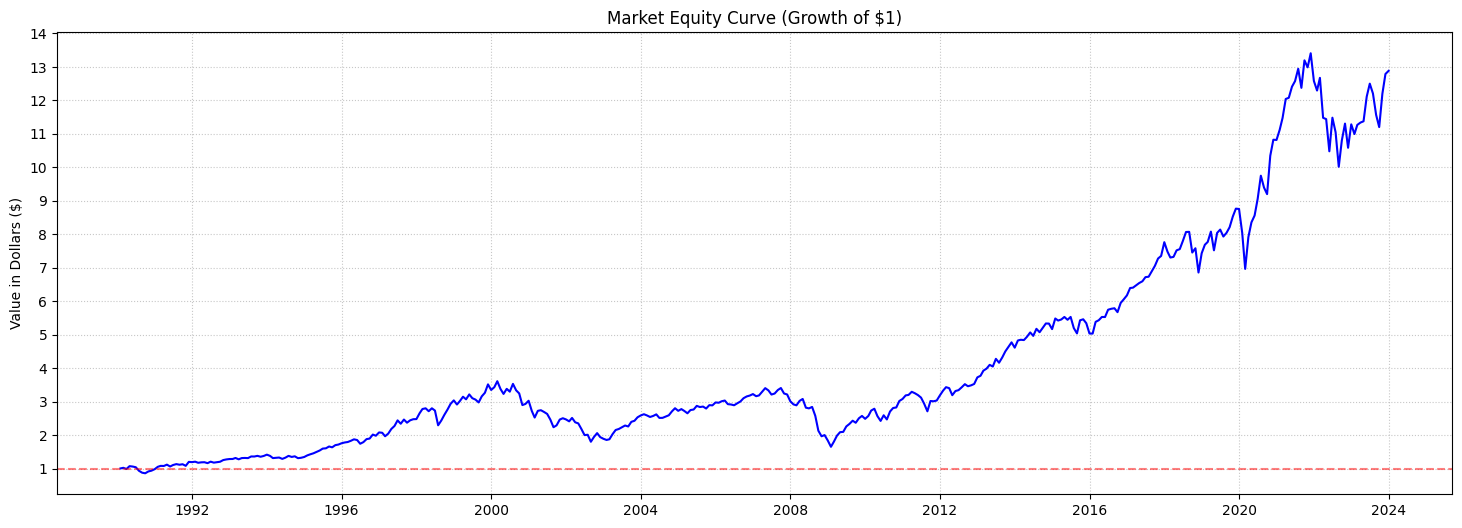

In [ ]:
# 1. Calculate the Equity Curve (decimal conversion included)
df['Cumulative_Mkt'] = (1 + (df['Mkt_RF'] / 100)).cumprod()

# 2. Plot
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(df.index, df['Cumulative_Mkt'], color='blue', linewidth=1.5)

# 3. Force Y-axis to show integers
# This tells Matplotlib to put a tick at every whole number
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# Optional: Add a horizontal line at 1.0 (your starting capital)
ax.axhline(1, color='red', linestyle='--', alpha=0.5)

plt.title('Market Equity Curve (Growth of $1)')
plt.ylabel('Value in Dollars ($)')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.show()

Equity Curve + VIX Plot

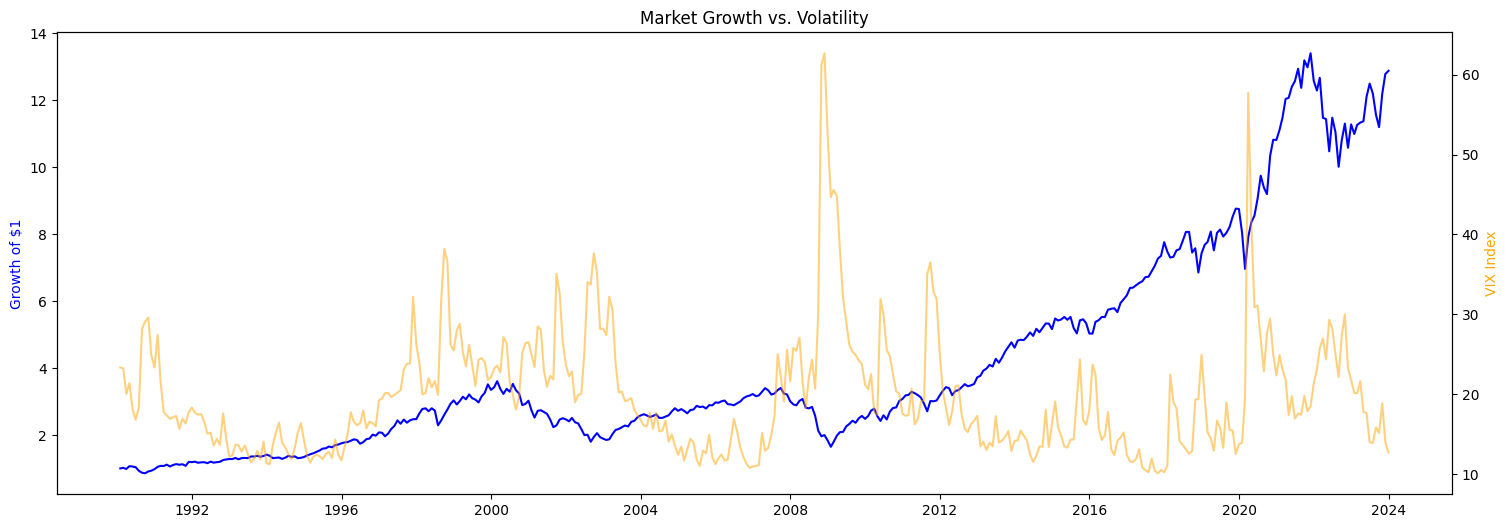

In [ ]:
fig, ax1 = plt.subplots(figsize=(18,6))

# Primary Axis: Cumulative Returns
ax1.plot(df.index, df['Cumulative_Mkt'], color='blue', label='Cumulative Mkt')
ax1.set_ylabel('Growth of $1', color='blue')

# Secondary Axis: VIX
ax2 = ax1.twinx()
ax2.plot(df.index, df['VIX'], color='orange', alpha=0.5, label='VIX')
ax2.set_ylabel('VIX Index', color='orange')

plt.title('Market Growth vs. Volatility')
plt.show()

Correlation Heat-Map

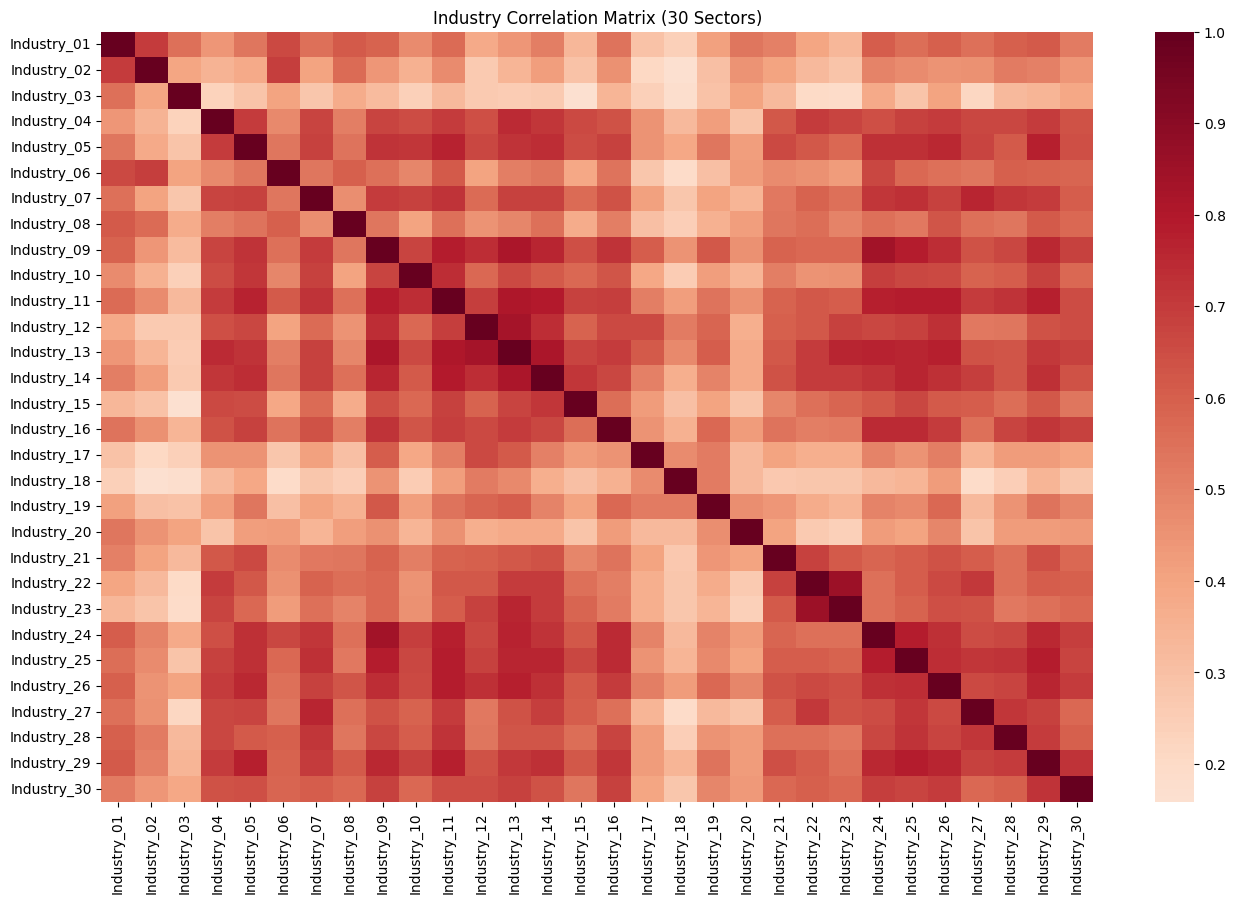

In [ ]:
# Slice columns B through AE (columns 1 to 31 if using index)
# Or use list comprehension if the columns are named exactly:
industry_cols = [f'Industry_{i:02}' for i in range(1, 31)]
corr_matrix = df[industry_cols].corr()

# View the correlation between Industry_01 and Industry_02
#print(corr_matrix.loc['Industry_01', 'Industry_02'])

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False)
plt.title('Industry Correlation Matrix (30 Sectors)')
plt.show()

12-Month Rolling Correlation

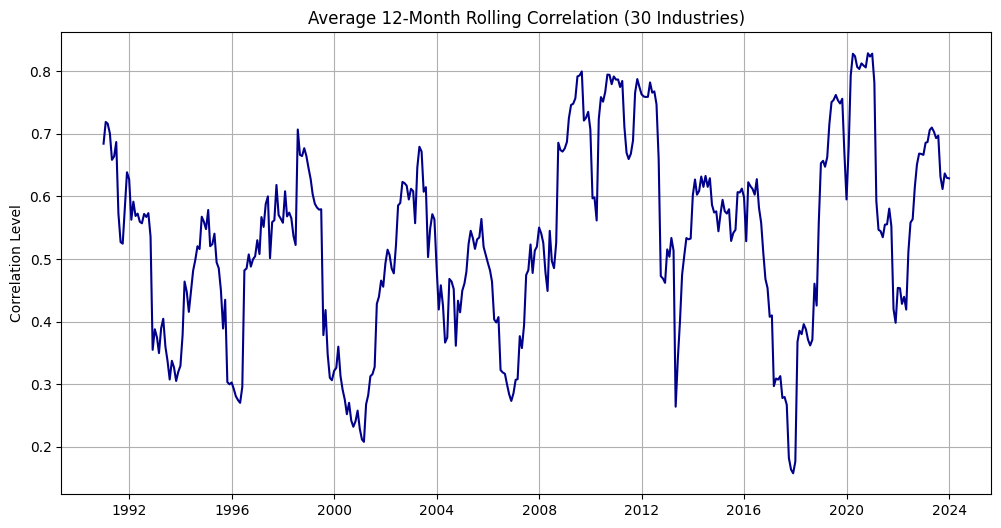

In [ ]:
# 1. Define window
window = 12

# 2. Calculate rolling correlation matrix
# This creates a complex index, so we take the mean of the rows
rolling_corr = df[industry_cols].rolling(window=window).corr()
avg_rolling_corr = rolling_corr.groupby(level=0).mean().mean(axis=1)

# 3. Plot it
plt.figure(figsize=(12,6))
plt.plot(avg_rolling_corr, color='darkblue')
plt.title(f'Average {window}-Month Rolling Correlation (30 Industries)')
plt.ylabel('Correlation Level')
plt.grid(True)
plt.show()

VIX vs Correlation Plot

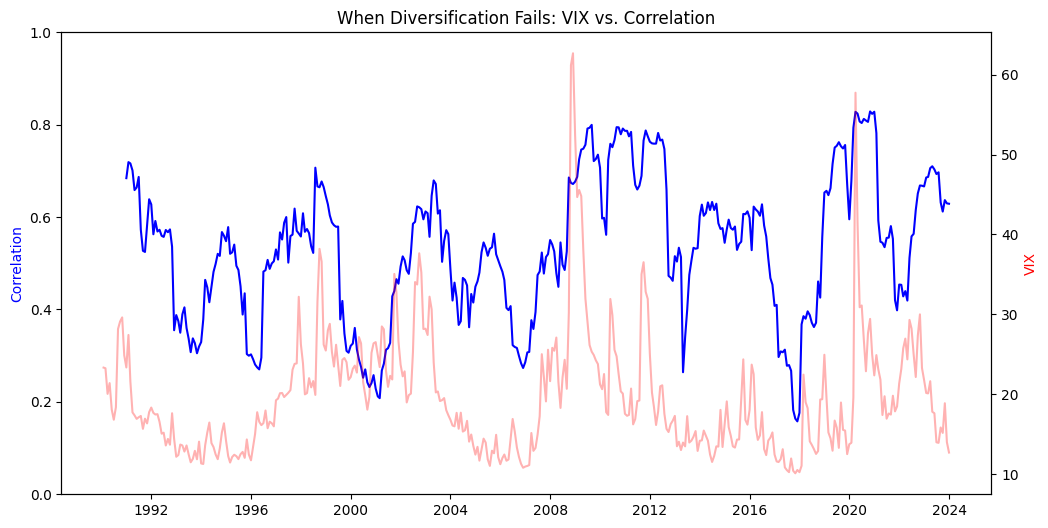

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Average Correlation (Monthly)
ax1.plot(avg_rolling_corr, color='blue', label='Avg Industry Correlation')
ax1.set_ylabel('Correlation', color='blue')
ax1.set_ylim(0, 1)

# Plot VIX on secondary axis
ax2 = ax1.twinx()
ax2.plot(df['VIX'], color='red', alpha=0.3, label='VIX (Fear Index)')
ax2.set_ylabel('VIX', color='red')

plt.title('When Diversification Fails: VIX vs. Correlation')
plt.show()

In [ ]:
industry_cols = [col for col in df.columns if col.startswith("Industry")]
macro_cols = ["Mkt_RF", "VIX", "Term_Spread"]

industries = df[industry_cols]
macro = df[macro_cols]

defining market volatility

In [ ]:
window = 12  # 12-month rolling window

# measuring market volatility by finding standard deviation in market excess return
df["Mkt_Vol"] = df["Mkt_RF"].rolling(window).std()


calculating rolling average of correlation

In [ ]:
def rolling_avg_corr(returns, window=12):
    avg_corr = []
    for i in range(len(returns)):
        if i < window:
            avg_corr.append(np.nan)
        else:
            corr_matrix = returns.iloc[i-window:i].corr()
            avg = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).mean().mean()
            avg_corr.append(avg)
    return avg_corr

df["Avg_Corr"] = rolling_avg_corr(industries, window)

In [ ]:
df_clean = df.dropna().copy() # remove all NaN rows

## 2 REGIME CLASSIFICATION (TERCILE)

In [ ]:
# initialising thresholds

vix_thresh = df_clean["VIX"].median()
corr_thresh = df_clean["Avg_Corr"].median()
vol_thresh = df_clean["Mkt_Vol"].median()

In [ ]:
# thresholds based on median of each parameter
df_clean["Stress_Regime"] = (
    (df_clean["VIX"] > vix_thresh) &
    (df_clean["Avg_Corr"] > corr_thresh)
).astype(int)

# stress thresholds based on the top 30th percentile of each percentile
df_clean["Stress_Regime"] = (
    (df["VIX"] > df["VIX"].quantile(0.7)) &
    (df["Mkt_Vol"] > df["Mkt_Vol"].quantile(0.7)) &
    (df["Avg_Corr"] > df["Avg_Corr"].quantile(0.7))
).astype(int)


In [ ]:
df_clean["Stress_Regime"].value_counts(normalize=True)

,proportion
Stress_Regime,
0,0.883838
1,0.116162


In [ ]:
df_clean.groupby("Stress_Regime")[["Mkt_RF", "VIX","Mkt_Vol", "Avg_Corr"]].median()

,Mkt_RF,VIX,Mkt_Vol,Avg_Corr
Stress_Regime,,,,
0,1.065,16.868896,3.660885,0.507820
1,4.355,28.498816,6.639590,0.715931


marking out stressed periods on a VIX graph

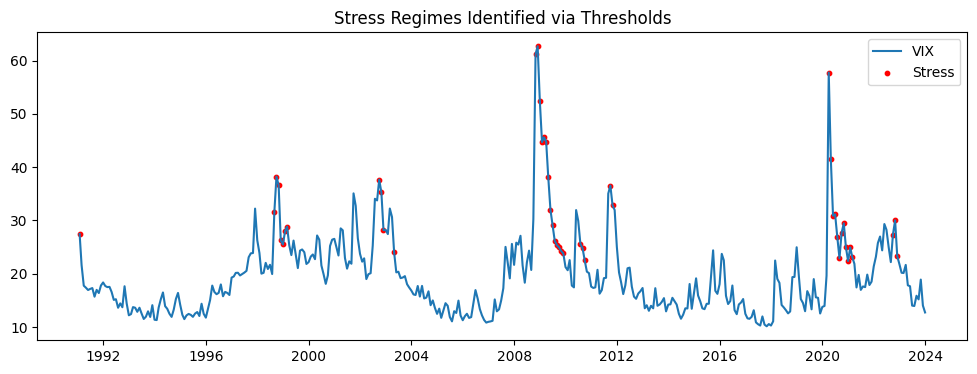

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_clean.index, df_clean["VIX"], label="VIX")
plt.scatter(df_clean.index[df_clean["Stress_Regime"]==1],
            df_clean["VIX"][df_clean["Stress_Regime"]==1],
            color="red", label="Stress", s=10)
plt.legend()
plt.title("Stress Regimes Identified via Thresholds")
plt.show()

#3 REGIME CLASSIFICATION (TERCILE)
assigning regimes into 3 groups equally based on percentiles

In [ ]:
q1 = df_clean["VIX"].quantile(0.33)
q2 = df_clean["VIX"].quantile(0.66)

def classify_vix(v):
    if v <= q1:
        return "Calm" # bottom 33rd
    elif v <= q2:
        return "Normal" # middle 33rd
    else:
        return "Stress" # high 33rd

# add to df
df_clean["Regime_Tercile"] = df_clean["VIX"].apply(classify_vix)

In [ ]:
df_clean.groupby("Regime_Tercile")[["VIX","Mkt_Vol","Avg_Corr","Mkt_RF"]].mean()

,VIX,Mkt_Vol,Avg_Corr,Mkt_RF
Regime_Tercile,,,,
Calm,12.944288,2.630987,0.439606,0.775649
Normal,17.720740,4.003120,0.549843,0.514462
Stress,27.532877,5.531180,0.563106,0.947704


In [ ]:
from sklearn.preprocessing import StandardScaler

features = df_clean[["VIX", "Mkt_Vol", "Avg_Corr"]] # features for stress_index
scaler = StandardScaler()
Z = scaler.fit_transform(features) # scaling all parameters so as to be compared fairly

df_clean["Stress_Index"] = Z.sum(axis=1)


assigning regimes based on stress indices

In [ ]:
q1 = df_clean["Stress_Index"].quantile(0.33)
q2 = df_clean["Stress_Index"].quantile(0.66)

def classify_stress(x):
    if x <= q1:
        return "Calm"
    elif x <= q2:
        return "Normal"
    else:
        return "Stress"

df_clean["Regime_Tercile"] = df_clean["Stress_Index"].apply(classify_stress)

In [ ]:
df_clean.groupby("Regime_Tercile")[["VIX","Mkt_Vol","Avg_Corr","Mkt_RF"]].mean()

,VIX,Mkt_Vol,Avg_Corr,Mkt_RF
Regime_Tercile,,,,
Calm,13.659087,2.343402,0.390686,0.918626
Normal,19.043008,3.968165,0.492685,-0.055308
Stress,25.565962,5.843906,0.665619,1.357630


proportions of the different regimes (tercile)

In [ ]:
df_clean["Regime_Tercile"].value_counts(normalize=True)

,proportion
Regime_Tercile,
Stress,0.340909
Calm,0.330808
Normal,0.328283


### marking out periods of calm, normal and stress on a stress_index plot

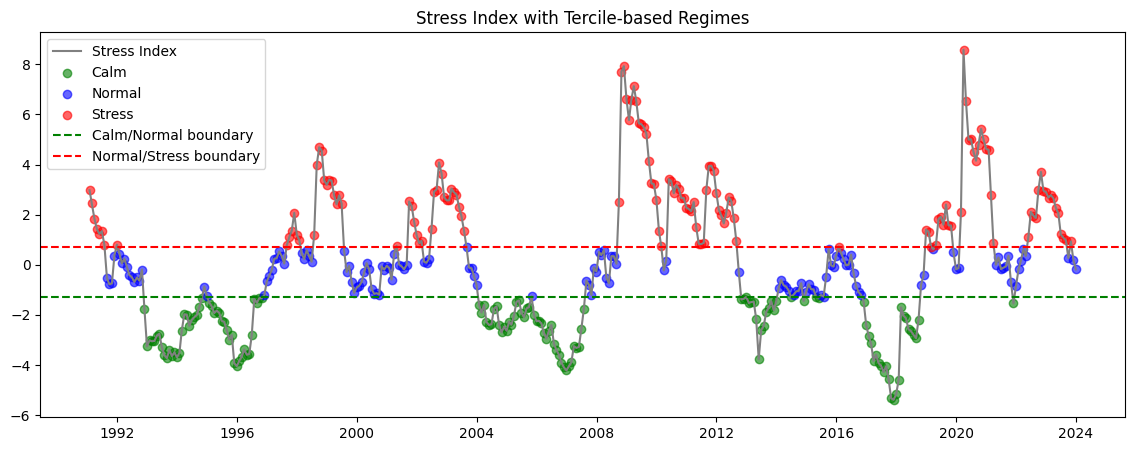

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_clean.index, df_clean["Stress_Index"], label="Stress Index", color="gray")

plt.scatter(df_clean[df_clean["Regime_Tercile"]=="Calm"].index,
            df_clean[df_clean["Regime_Tercile"]=="Calm"]["Stress_Index"],
            label="Calm", color="green", alpha=0.6)

plt.scatter(df_clean[df_clean["Regime_Tercile"]=="Normal"].index,
            df_clean[df_clean["Regime_Tercile"]=="Normal"]["Stress_Index"],
            label="Normal", color="blue", alpha=0.6)

plt.scatter(df_clean[df_clean["Regime_Tercile"]=="Stress"].index,
            df_clean[df_clean["Regime_Tercile"]=="Stress"]["Stress_Index"],
            label="Stress", color="red", alpha=0.6)

plt.axhline(df_clean["Stress_Index"].quantile(0.33), color="green", linestyle="--", label="Calm/Normal boundary")
plt.axhline(df_clean["Stress_Index"].quantile(0.66), color="red", linestyle="--", label="Normal/Stress boundary")

plt.legend()
plt.title("Stress Index with Tercile-based Regimes")
plt.show()


### shading regions of different regimes for cleaner visualization

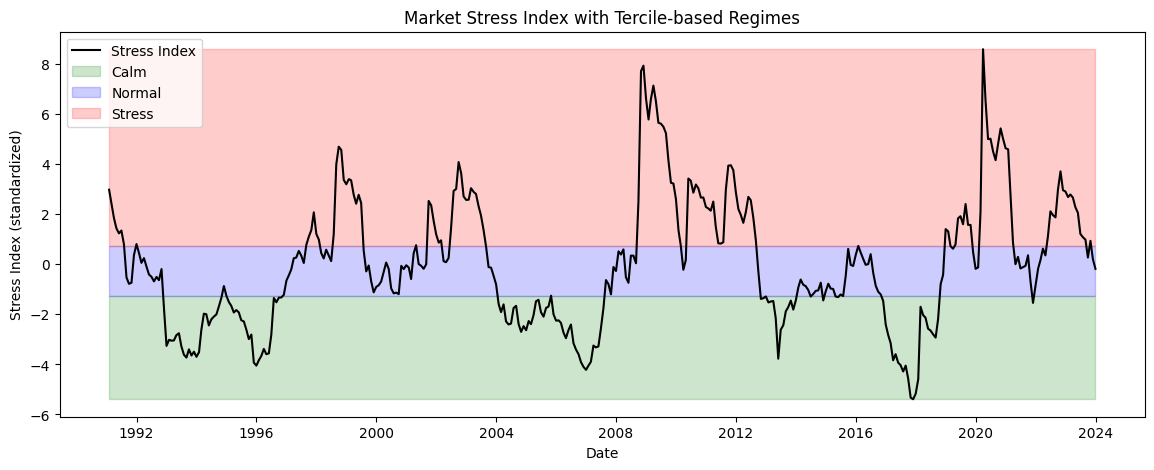

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Plot the Stress Index line
plt.plot(df_clean.index, df_clean["Stress_Index"], color='black', label="Stress Index")

# Add colored bands for regimes
plt.fill_between(df_clean.index, df_clean["Stress_Index"].min(), q1, color='green', alpha=0.2, label='Calm')
plt.fill_between(df_clean.index, q1, q2, color='blue', alpha=0.2, label='Normal')
plt.fill_between(df_clean.index, q2, df_clean["Stress_Index"].max(), color='red', alpha=0.2, label='Stress')

plt.title("Market Stress Index with Tercile-based Regimes")
plt.ylabel("Stress Index (standardized)")
plt.xlabel("Date")
plt.legend(loc='upper left')
plt.show()


overviewing how different parameters look in different regimes

In [ ]:
df_clean.groupby("Regime_Tercile")[["VIX","Mkt_Vol","Avg_Corr","Stress_Index"]].mean()

,VIX,Mkt_Vol,Avg_Corr,Stress_Index
Regime_Tercile,,,,
Calm,13.659087,2.343402,0.390686,-2.609061
Normal,19.043008,3.968165,0.492685,-0.279026
Stress,25.565962,5.843906,0.665619,2.800447


#HIDDEN MARKOV MODEL (CLASSIFICATION OF REGIMES)

In [ ]:
print(df_clean["Stress_Index"])

Date
1991-01-31    2.975101
1991-02-28    2.448319
1991-03-31    1.846011
1991-04-30    1.433882
1991-05-31    1.231945
                ...   
2023-08-31    0.980536
2023-09-30    0.266236
2023-10-31    0.933533
2023-11-30    0.196926
2023-12-31   -0.185998
Name: Stress_Index, Length: 396, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

#features = df_clean[["Stress_Index", "Mkt_Vol", "Avg_Corr"]].dropna()
features = df_clean[["Mkt_Vol", "Avg_Corr","Stress_Index"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [ ]:
from hmmlearn.hmm import GaussianHMM

hmm_model = GaussianHMM(
    n_components=3,        #number of latent regimes
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

# fit the model
hmm_model.fit(X_scaled)

# extract regime labels
hidden_states = hmm_model.predict(X_scaled)
df_clean.loc[features.index, "HMM_State"] = hidden_states # add to df



In [ ]:
state_probs = hmm_model.predict_proba(X_scaled)

for i in range(hmm_model.n_components):
    df_clean.loc[features.index, f"HMM_Prob_State_{i}"] = state_probs[:, i]


In [ ]:
df_clean.groupby("HMM_State")[["Mkt_Vol", "Avg_Corr","Stress_Index", "Mkt_RF","VIX","Term_Spread"]].mean()

,Mkt_Vol,Avg_Corr,Stress_Index,Mkt_RF,VIX,Term_Spread
HMM_State,,,,,,
0.0,6.035255,0.661273,3.350859,1.590222,29.083479,1.522000
1.0,4.566907,0.532689,0.388965,0.009673,19.462260,1.611895
2.0,2.417415,0.418767,-2.360058,0.992353,13.863382,1.745621


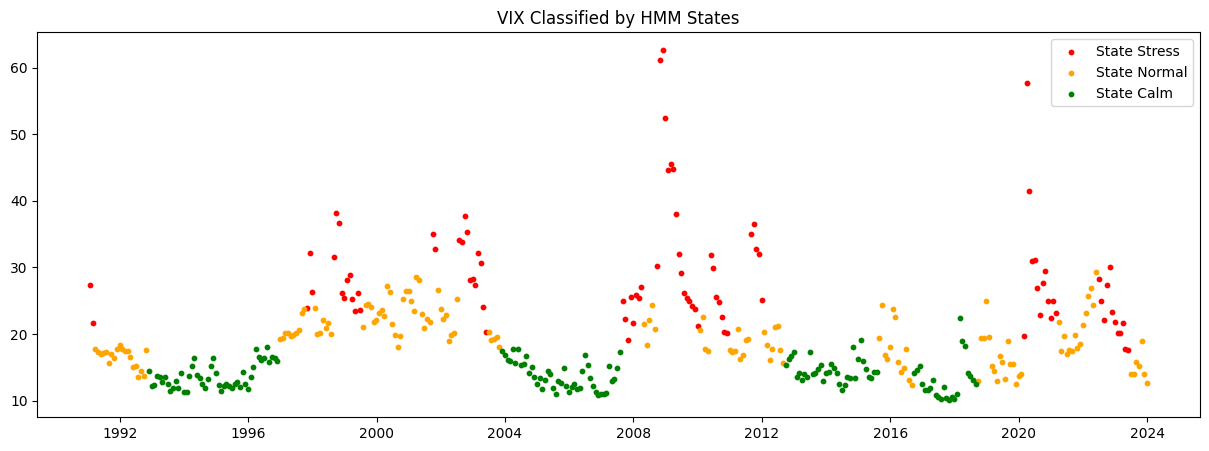

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
# Define colors for clarity: 0 (Red/Panic), 1 (Orange/Turbulent), 2 (Green/Quiet)
# Note: Check your HMM_State means to ensure labels match these colors
colors = {0: 'red', 1: 'orange', 2: 'green'}
labela = {0: 'Stress',1:'Normal',2:'Calm'}

for state in range(hmm_model.n_components):
    mask = df_clean['HMM_State'] == state
    plt.scatter(df_clean.index[mask], df_clean['VIX'][mask],
                color=colors[state], label=f'State {labela[state]}', s=10)

plt.title("VIX Classified by HMM States")
plt.legend()
plt.show()

In [ ]:
state_map = {
    0: "Stress",
    1: "Normal",
    2: "Calm"
}

df_clean["HMM_Regime"] = df_clean["HMM_State"].map(state_map)


#CHECKING COMPATIBILITY OF TERCILE AND HMM

In [ ]:
pd.crosstab(df_clean["Regime_Tercile"], df_clean["HMM_Regime"])


HMM_Regime,Calm,Normal,Stress
Regime_Tercile,,,
Calm,129,2,0
Normal,24,98,8
Stress,0,53,82


In [ ]:
(df_clean["Regime_Tercile"] == df_clean["HMM_Regime"]).mean()*100

np.float64(78.03030303030303)

##Comparison of features between HMM_Regime and Tercile_Regime

In [ ]:
df_clean.groupby("HMM_Regime")[["Mkt_Vol", "Avg_Corr","Stress_Index", "Mkt_RF","VIX","Term_Spread"]].mean()

,Mkt_Vol,Avg_Corr,Stress_Index,Mkt_RF,VIX,Term_Spread
HMM_Regime,,,,,,
Calm,2.417415,0.418767,-2.360058,0.992353,13.863382,1.745621
Normal,4.566907,0.532689,0.388965,0.009673,19.462260,1.611895
Stress,6.035255,0.661273,3.350859,1.590222,29.083479,1.522000


In [ ]:
df_clean.groupby("Regime_Tercile")[["Mkt_Vol", "Avg_Corr","Stress_Index", "Mkt_RF","VIX","Term_Spread"]].mean()

,Mkt_Vol,Avg_Corr,Stress_Index,Mkt_RF,VIX,Term_Spread
Regime_Tercile,,,,,,
Calm,2.343402,0.390686,-2.609061,0.918626,13.659087,1.656107
Normal,3.968165,0.492685,-0.279026,-0.055308,19.043008,1.664769
Stress,5.843906,0.665619,2.800447,1.357630,25.565962,1.609704


In [ ]:
df_clean["Disagreement"] = df_clean["Regime_Tercile"] != df_clean["HMM_Regime"]

frequency of regime changes

In [ ]:
df_clean["Tercile_Change"] = df_clean["Regime_Tercile"].ne(df_clean["Regime_Tercile"].shift())
df_clean["HMM_Change"] = df_clean["HMM_Regime"].ne(df_clean["HMM_Regime"].shift())

df_clean[["Tercile_Change", "HMM_Change"]].mean()


,0
Tercile_Change,0.126263
HMM_Change,0.073232


##checking whether tercile regime leads HMM regime

In [ ]:
# Shift Tercile by 1 month to see if it predicts HMM
df_clean["Tercile_Lead"] = df_clean["Regime_Tercile"].shift(1)

# Compare with HMM next month
lead_lag_matrix = pd.crosstab(df_clean["Tercile_Lead"], df_clean["HMM_Regime"])
print(lead_lag_matrix)

HMM_Regime    Calm  Normal  Stress
Tercile_Lead                      
Calm           127       3       1
Normal          25      93      11
Stress           1      57      77


In [ ]:
df_clean["HMM_Num"] = df_clean["HMM_Regime"].map({"Calm":0, "Normal":1, "Stress":2})
df_clean["Tercile_Lead_Num"] = df_clean["Regime_Tercile"].shift(1).map({"Calm":0, "Normal":1, "Stress":2})
df_clean["Tercile_Num"] = df_clean["Regime_Tercile"].map({"Calm":0, "Normal":1, "Stress":2})

df_clean[["Tercile_Lead_Num","HMM_Num"]].corr()


,Tercile_Lead_Num,HMM_Num
Tercile_Lead_Num,1.000000,0.816464
HMM_Num,0.816464,1.000000


In [ ]:
df_clean[["Tercile_Num", "HMM_Num"]].corr()

,Tercile_Num,HMM_Num
Tercile_Num,1.000000,0.850209
HMM_Num,0.850209,1.000000


#JOINT REGIME (FINAL REGIME)



In [ ]:
df_clean["Joint_Regime"] = df_clean["Regime_Tercile"].astype(str) + "_" + df_clean["HMM_Regime"].astype(str)

joint_counts = df_clean["Joint_Regime"].value_counts()
print(joint_counts)


Joint_Regime
Calm_Calm        129
Normal_Normal     98
Stress_Stress     82
Stress_Normal     53
Normal_Calm       24
Normal_Stress      8
Calm_Normal        2
Name: count, dtype: int64


In [ ]:
risk_metrics = df_clean.groupby("Joint_Regime")[["Mkt_RF","Mkt_Vol","Avg_Corr","Stress_Index","VIX",]].mean()
print(risk_metrics)


                 Mkt_RF   Mkt_Vol  Avg_Corr  Stress_Index        VIX
Joint_Regime                                                        
Calm_Calm      0.967132  2.328614  0.390930     -2.620574  13.627360
Calm_Normal   -2.210000  3.297185  0.374910     -1.866463  15.705501
Normal_Calm    1.127917  2.894722  0.568391     -0.959786  15.132002
Normal_Normal -0.284184  4.313754  0.473548     -0.119580  19.596666
Normal_Stress -0.801250  2.955028  0.499995     -0.189961  23.993720
Stress_Normal  0.636792  5.082915  0.647998      1.414403  19.355500
Stress_Stress  1.823537  6.335765  0.677008      3.696305  29.580041


In [ ]:
# Convert HMM regime to stress probability (e.g., 0,1,2 → normalize 0-1)
df_clean["HMM_Stress_Score"] = df_clean["HMM_Num"] / 2

# Stress index already normalized
df_clean["Hybrid_Stress"] = 0.5 * df_clean["Stress_Index"] + 0.5 * df_clean["HMM_Stress_Score"]

HMM is slower to react to switches of regimes, while <br>
Tercile is much quick to react which could result in a few false signals

In [ ]:
agreement_states = ["Calm_Calm", "Normal_Normal", "Stress_Stress"]

df_clean["Agreement_Flag"] = df_clean["Joint_Regime"].apply(
    lambda x: "Agreement" if x in agreement_states else "Disagreement"
)

disagree_df = df_clean[df_clean["Agreement_Flag"] == "Disagreement"]

disagree_df[["Joint_Regime", "Mkt_RF", "Mkt_Vol", "Avg_Corr", "VIX"]].describe()

agree_df = df_clean[df_clean["Agreement_Flag"] == "Agreement"]

agree_df[["Mkt_RF","Mkt_Vol","Avg_Corr","VIX"]].mean(), \
disagree_df[["Mkt_RF","Mkt_Vol","Avg_Corr","VIX"]].mean()


(Mkt_RF       0.797540
 Mkt_Vol      4.021592
 Avg_Corr     0.493049
 VIX         19.753935
 dtype: float64,
 Mkt_RF       0.574598
 Mkt_Vol      4.242557
 Avg_Corr     0.606150
 VIX         18.532992
 dtype: float64)

###disagreement months bw regime-detection models

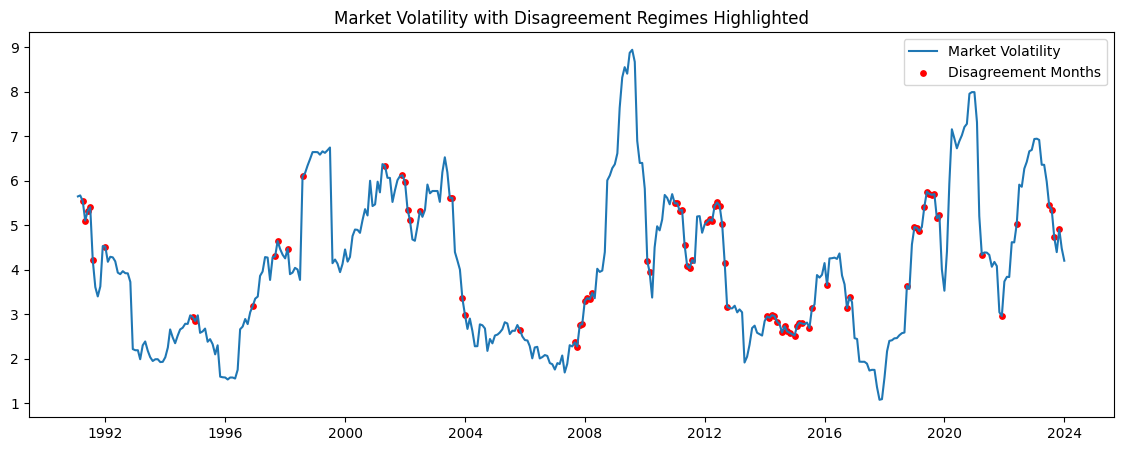

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df_clean.index, df_clean["Mkt_Vol"], label="Market Volatility")

# highlight disagreement months
plt.scatter(
    disagree_df.index,
    disagree_df["Mkt_Vol"],
    color="red",
    label="Disagreement Months",
    s=15
)

plt.title("Market Volatility with Disagreement Regimes Highlighted")
plt.legend()
plt.show()


In [ ]:
stress_disagree = df_clean[
    (df_clean["Joint_Regime"]=="Stress_Normal") |
    (df_clean["Joint_Regime"]=="Normal_Stress")
]

stress_agree = df_clean[
    (df_clean["Joint_Regime"]=="Stress_Stress")
]

normal_agree = df_clean[
    (df_clean["Joint_Regime"]=="Normal_Normal")
]

calm_agree = df_clean[
    (df_clean["Joint_Regime"]=="Calm_Calm")
]

### regime models agreement
* the features are similar when the models disagree on stress and agree on normal

* this means that when the models disagree on stress, we should classify that as normal instead of taking a risk safe approach and consider stress

In [ ]:
stress_disagree[["Mkt_RF","VIX","Mkt_Vol"]].describe()

,Mkt_RF,VIX,Mkt_Vol
count,61.000000,61.000000,61.000000
mean,0.448197,19.963791,4.803848
std,4.581019,3.938487,0.935674
min,-16.050000,12.949048,2.272749
25%,-2.300000,17.135000,4.214685
50%,1.410000,19.161364,5.097586
75%,3.420000,22.875789,5.437697
max,8.880000,29.313636,6.335907


In [ ]:
normal_agree[["Mkt_RF","VIX","Mkt_Vol"]].describe()

,Mkt_RF,VIX,Mkt_Vol
count,98.000000,98.000000,98.000000
mean,-0.284184,19.596666,4.313754
std,4.794252,3.758312,0.675769
min,-10.700000,12.399565,3.042889
25%,-3.067500,17.418214,3.903069
50%,0.300000,19.674886,4.193678
75%,3.162500,22.090000,4.521824
max,10.850000,28.496818,6.370940


In [ ]:
calm_agree[["Mkt_RF","VIX","Mkt_Vol"]].describe()

,Mkt_RF,VIX,Mkt_Vol
count,129.000000,129.000000,129.000000
mean,0.967132,13.627360,2.328614
std,2.414591,2.171934,0.449878
min,-5.960000,10.125455,1.076151
25%,-0.300000,11.975652,1.987765
50%,1.280000,13.338500,2.386189
75%,2.800000,15.033000,2.659988
max,6.250000,22.464737,3.269220


In [ ]:
stress_agree[["Mkt_RF","VIX","Mkt_Vol"]].describe()

,Mkt_RF,VIX,Mkt_Vol
count,82.000000,82.000000,82.000000
mean,1.823537,29.580041,6.335765
std,6.031968,9.025906,1.039177
min,-17.200000,17.636087,4.150615
25%,-2.365000,23.809467,5.701132
50%,2.805000,27.426688,6.346331
75%,6.130000,32.215344,6.850797
max,13.600000,62.668947,8.939546


In [ ]:
df_clean["True_Stress"] = (
    (df_clean["HMM_Regime"] == "Stress") &
    (df_clean["Regime_Tercile"] == "Stress")
).astype(int)


###how features look during a period when the regime detectors disagree on stress

In [ ]:
stress_normal = df_clean[
    (df_clean["Regime_Tercile"]=="Stress") &
    (df_clean["HMM_Regime"]=="Normal")
]

window_data = []

for idx in stress_normal.index:
    block = df_clean.loc[idx:].iloc[:6]  # T, T+1, T+2
    pre = df_clean.loc[:idx].iloc[-5:-1] # T-2, T-1

    combined = pd.concat([pre, block])
    combined["Event_Date"] = idx
    window_data.append(combined)

event_window = pd.concat(window_data)

def rel_time_label(event_date, dates):
    return [(d - event_date).days//30 for d in dates]

event_window["Rel_Month"] = event_window.groupby("Event_Date").apply(
    lambda x: rel_time_label(x.name, x.index)
).explode().values

avg_profile = event_window.groupby("Rel_Month")[["Mkt_RF","Mkt_Vol","VIX","Avg_Corr"]].mean()
print(avg_profile)


             Mkt_RF   Mkt_Vol        VIX  Avg_Corr
Rel_Month                                         
-5         1.627250  5.286285  21.415586  0.640839
-4         1.798654  5.174516  21.064157  0.631317
-3         0.541818  5.306364  20.397877  0.636883
-2         0.978333  5.214927  19.948416  0.664455
-1         2.257000  5.311921  20.097237  0.638045
 0         1.011167  5.032249  19.414308  0.645128
 1         0.532593  4.877174  18.954243  0.646497
 2        -0.649400  4.706781  19.260404  0.631783
 3         0.440000  4.664707  20.118349  0.624458
 4         0.592115  4.603772  20.117306  0.621693
 5         0.660588  4.589426  21.177698  0.623172


/tmp/ipython-input-1708442762.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  event_window["Rel_Month"] = event_window.groupby("Event_Date").apply(


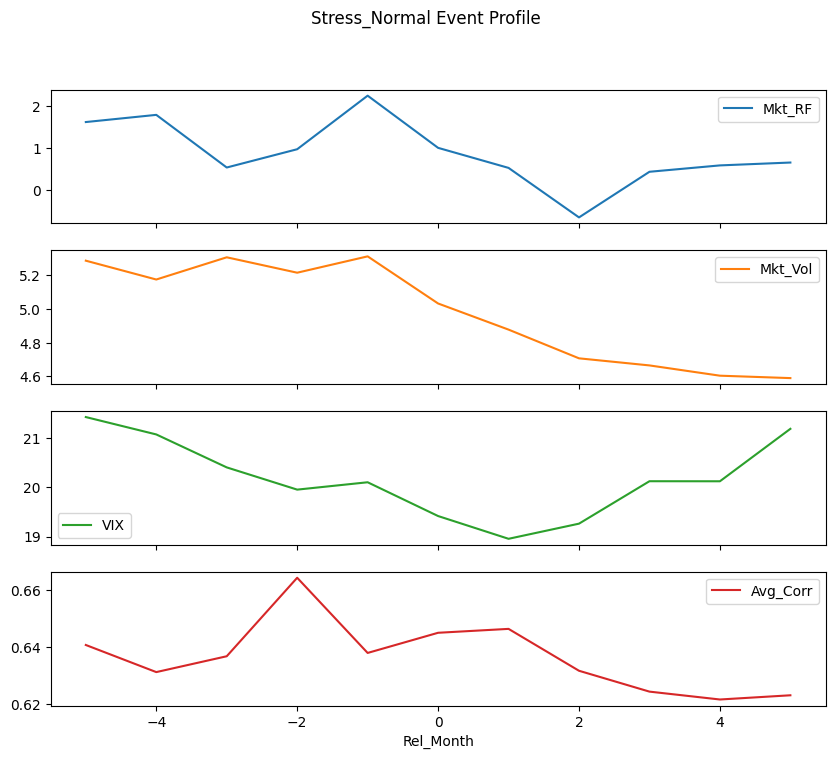

In [ ]:
import matplotlib.pyplot as plt

avg_profile.plot(subplots=True, figsize=(10,8), title="Stress_Normal Event Profile")
plt.show()


In [ ]:
true_stress = df_clean[
    (df_clean["Regime_Tercile"]=="Stress") &
    (df_clean["HMM_Regime"]=="Stress")
]


#PORTFOLIO LOGIC - 1

creating final regime

In [ ]:
def combine_regimes(row):
    tercile = row["Regime_Tercile"]
    hmm = row["HMM_Regime"]

    if tercile == hmm:
        return tercile
    elif tercile == "Stress" and hmm == "Normal":
        return hmm
    else:
        # take the riskier regime
        hierarchy = {"Calm": 0, "Normal": 1, "Stress": 2}
        return tercile if hierarchy[tercile] > hierarchy[hmm] else hmm

df_clean["Final_Regime"] = df_clean.apply(combine_regimes, axis=1)


###assiging different categories for varies industries by using a score

In [ ]:
betas = {}
for col in industries.columns:
    cov = np.cov(df_clean[col], df_clean["Mkt_RF"])[0,1]
    var = np.var(df_clean["Mkt_RF"])
    betas[col] = cov / var

beta_series = pd.Series(betas).sort_values()

stress_returns = df_clean[df_clean["Final_Regime"]=="Stress"][industries.columns].mean()
stress_returns.sort_values()

vols = df_clean[industries.columns].std()
vols.sort_values()

# --------------------------------------------------

score = pd.DataFrame({
    "Beta": beta_series,
    "Stress_Return": stress_returns,
    "Volatility": vols
})

# Normalize
score_norm = (score - score.mean()) / score.std()

# Final score: higher = more cyclical
score_norm["Cyclicality_Score"] = (
    score_norm["Beta"]
    - score_norm["Stress_Return"]
    + score_norm["Volatility"]
)

score_norm.sort_values("Cyclicality_Score")

# assigning buckets

score_norm["Bucket"] = pd.qcut(
    score_norm["Cyclicality_Score"],
    q=3,
    labels=["Defensive", "Neutral", "Cyclical"]
)



In [ ]:
# Show the industry and assigned bucket
print(score_norm[["Bucket", "Cyclicality_Score"]].sort_values("Cyclicality_Score"))


                Bucket  Cyclicality_Score
Industry_01  Defensive          -1.759845
Industry_20  Defensive          -1.691025
Industry_08  Defensive          -1.515793
Industry_28  Defensive          -1.452292
Industry_06  Defensive          -1.424442
Industry_02  Defensive          -1.329683
Industry_27  Defensive          -1.274664
Industry_03  Defensive          -0.491864
Industry_26  Defensive          -0.463440
Industry_21  Defensive          -0.363221
Industry_25    Neutral          -0.362220
Industry_17    Neutral          -0.306494
Industry_09    Neutral          -0.240199
Industry_22    Neutral          -0.217246
Industry_24    Neutral          -0.202690
Industry_13    Neutral           0.085190
Industry_19    Neutral           0.172567
Industry_14    Neutral           0.215760
Industry_07    Neutral           0.223204
Industry_23    Neutral           0.323103
Industry_16   Cyclical           0.324852
Industry_11   Cyclical           0.368392
Industry_30   Cyclical           0

In [ ]:
# Define min/max exposure per regime
regime_limits = {
    "Calm": {"min": 0.9, "max": 1.0},
    "Normal": {"min": 0.8, "max": 0.9},
    "Stress": {"min": 0.6, "max": 0.7}
}

# Normalize Stress Index (0-1)
stress_norm = (df_clean["Stress_Index"] - df_clean["Stress_Index"].min()) / \
              (df_clean["Stress_Index"].max() - df_clean["Stress_Index"].min())

# Function to calculate exposure per month
def calculate_exposure(row):
    regime = row["Final_Regime"]
    limits = regime_limits[regime]
    exposure = limits["max"] - (limits["max"] - limits["min"]) * stress_norm[row.name]
    return exposure

df_clean["Total_Exposure"] = df_clean.apply(calculate_exposure, axis=1)




#PORTFOLIO LOGIC - 2 (Continuous Distribution)

In [ ]:
# Hard align everything to the same index
common_index = industries.index.intersection(df_clean.index)

industries = industries.loc[common_index]
df_clean = df_clean.loc[common_index]

# Future returns (t+1)
industries_fwd = industries.shift(-1)

# Market return at t+1
mkt_fwd = df_clean["Mkt_RF"].shift(-1)

# Fear variables at t
dVIX = df_clean["VIX"].diff()
dTS  = df_clean["Term_Spread"].diff()

# Align
data = industries_fwd.join([mkt_fwd, dVIX, dTS, df_clean["Final_Regime"]]).dropna()



In [ ]:

def max_drawdown(r):
    r = r / 100
    cum = (1 + r).cumprod()
    return (cum / cum.cummax() - 1).min()

def cvar_5(r):
    r = r / 100
    var = np.percentile(r, 5)
    return r[r <= var].mean()


regime_stats = {}

for regime in ["Calm", "Normal", "Stress"]:
    mask = data["Final_Regime"] == regime

    stats = pd.DataFrame(index=industries.columns)
    stats["Mean"]  = data.loc[mask, industries.columns].mean()
    stats["Vol"]   = data.loc[mask, industries.columns].std()
    stats["MaxDD"] = data.loc[mask, industries.columns].apply(max_drawdown)
    stats["CVaR"]  = data.loc[mask, industries.columns].apply(cvar_5)

    regime_stats[regime] = stats


In [ ]:
import statsmodels.api as sm

vix_beta = {}

for regime in ["Calm", "Normal", "Stress"]:
    mask = data["Final_Regime"] == regime
    betas = {}

    for ind in industries.columns:
        y = data.loc[mask, ind]
        X = sm.add_constant(data.loc[mask, ["Mkt_RF", "VIX"]])
        res = sm.OLS(y, X).fit()
        betas[ind] = res.params["VIX"]

    vix_beta[regime] = pd.Series(betas)


In [ ]:
# 1. Compute rolling volatility (3-month)
rolling_vol = industries.rolling(3).std()

# 2. Align rolling vol with data index
rolling_vol = rolling_vol.loc[data.index]

vol_trans = {}

for regime in ["Calm", "Normal", "Stress"]:
    mask = data["Final_Regime"] == regime
    gammas = {}

    for ind in industries.columns:
        y = rolling_vol.loc[mask, ind]
        X = sm.add_constant(dVIX.loc[data.index].loc[mask])

        # Drop missing rows explicitly
        df_reg = pd.concat([y, X], axis=1).dropna()

        if len(df_reg) < 10:
            gammas[ind] = np.nan
            continue

        res = sm.OLS(df_reg.iloc[:, 0], df_reg.iloc[:, 1:]).fit()
        gammas[ind] = res.params.iloc[1]  # coefficient on ΔVIX

    vol_trans[regime] = pd.Series(gammas)



In [ ]:
def score_industries(regime):
    s = regime_stats[regime].copy()

    s["VIX_Beta"] = vix_beta[regime]
    s["Vol_Trans"] = vol_trans[regime]

    z = (s - s.mean()) / s.std()

    if regime == "Calm":
        score = (
            z["Mean"]
            - 0.3 * z["Vol"]
        )

    elif regime == "Normal":
        score = (
            z["Mean"]
            - 0.5 * z["Vol"]
            - 0.3 * z["VIX_Beta"]
        )

    else:  # Stress
        score = (
            z["Mean"]
            - z["Vol"]
            - z["CVaR"]
            - z["MaxDD"]
            - z["VIX_Beta"]
            - z["Vol_Trans"]
        )

    return score.sort_values(ascending=False)


In [ ]:
def score_to_weights(score, max_weight=0.08, temperature=0.7):
    s = score - score.mean()
    w = np.exp(s / temperature)
    w = w / w.sum()
    w = np.minimum(w, max_weight)
    return w / w.sum()


In [ ]:


regime_scores = {
    r: score_industries(r) for r in ["Calm", "Normal", "Stress"]
}

regime_weights = {
    r: score_to_weights(regime_scores[r]) for r in regime_scores
}

weights_ts = pd.DataFrame(index=industries.index, columns=industries.columns)

for t in weights_ts.index:
    r = df_clean.loc[t, "Final_Regime"]
    weights_ts.loc[t] = regime_weights[r]



In [ ]:
weights_ts = weights_ts.mul(df_clean["Total_Exposure"], axis=0)
weights_ts["Cash"] = 1 - df_clean["Total_Exposure"]

returns_with_cash = industries.copy()
returns_with_cash["Cash"] = 0.0

final_continuous_returns = (
    weights_ts.shift(1) * returns_with_cash
).sum(axis=1)



###calculating weights of benchmark portfolios

In [ ]:
# Example weights dictionary
regime_weights = {
    "Calm": {"Defensive": 0.2, "Neutral": 0.3, "Cyclical": 0.5},
    "Normal": {"Defensive": 0.3, "Neutral": 0.4, "Cyclical": 0.3},
    "Stress": {"Defensive": 0.55, "Neutral": 0.3, "Cyclical": 0.15}
}

# Map each industry to bucket
industry_bucket = score_norm["Bucket"].to_dict()

# Create function to assign weights per month
def assign_weights(row):
    regime = row["Final_Regime"]
    weights = {}
    for industry in industries.columns:
        bucket = industry_bucket[industry]
        weights[industry] = regime_weights[regime][bucket]
    # normalize to sum to 1
    total = sum(weights.values())
    for k in weights:
        weights[k] /= total
    return pd.Series(weights)

portfolio_weights = df_clean.apply(assign_weights, axis=1)


In [ ]:
# Equal-weight benchmark weights
equal_weights = pd.DataFrame(
    np.repeat(1/industries.shape[1], industries.shape[1])[None, :],
    index=[industries.index[0]],
    columns=industries.columns
).reindex(industries.index, method="ffill")

# market benchmark
benchmark_market = df_clean["Mkt_RF"]

# ----------------------------------

# tercile benchmark
def assign_weights_tercile(row):
    regime = row["Regime_Tercile"]
    weights = {}
    for industry in industries.columns:
        bucket = industry_bucket[industry]
        weights[industry] = regime_weights[regime][bucket]
    total = sum(weights.values())
    for k in weights:
        weights[k] /= total
    return pd.Series(weights)

tercile_weights_df = df_clean.apply(assign_weights_tercile, axis=1)

# hmm benchmark
def assign_weights_hmm(row):
    regime = row["HMM_Regime"]
    weights = {}
    for industry in industries.columns:
        bucket = industry_bucket[industry]  # same bucket mapping as before
        weights[industry] = regime_weights[regime][bucket]
    total = sum(weights.values())
    for k in weights:
        weights[k] /= total
    return pd.Series(weights)

hmm_weights_df = df_clean.apply(assign_weights_hmm, axis=1)


####Applying exposure to portfolio weights

In [ ]:
# Apply to portfolio weights
portfolio_weights_scaled = portfolio_weights.mul(
    df_clean["Total_Exposure"], axis=0
)

# Optional: allocate remaining cash
portfolio_weights_scaled["Cash"] = 1 - df_clean["Total_Exposure"]

####Calculating returns

In [ ]:
# Ensure returns are in decimal form
industries_dec = industries / 100

# Cash column (assume 0% return)
portfolio_weights_scaled["Cash"] = portfolio_weights_scaled.get("Cash", 0)

# Add a dummy cash return column (0% monthly return)
returns_df_cash = industries_dec.copy()
returns_df_cash["Cash"] = 0.0

# Calculate monthly portfolio returns
final_regime_scaled_returns = (
    portfolio_weights_scaled * returns_df_cash
).sum(axis=1)


In [ ]:
# assume cash earns 0%
cash_returns = 0

# total portfolio return accounting for reduced exposure
total_portfolio_returns = (portfolio_weights_scaled.shift(1) * industries).sum(axis=1) * df_clean["Total_Exposure"] + \
                          cash_returns * (1 - df_clean["Total_Exposure"])


final_portfolio_returns = (portfolio_weights_scaled.shift(1) * industries).sum(axis=1)
equal_returns = (equal_weights.shift(1) * industries).sum(axis=1)
tercile_returns = (tercile_weights_df.shift(1) * industries).sum(axis=1)
market_returns = df_clean["Mkt_RF"]
hmm_portfolio_returns = (hmm_weights_df.shift(1) * industries).sum(axis=1)



In [ ]:
returns_df = pd.DataFrame({
    "Final_Regime_Portfolio": final_portfolio_returns,
    "Equal_Weighted": equal_returns,
    "Tercile_Only": tercile_returns,
    "Market": market_returns,

    "Final_Regime": df_clean["Final_Regime"]
})
returns_df["HMM_Portfolio"] = hmm_portfolio_returns

# Add new portfolio to existing returns_df
returns_df["Final_Regime_Scaled"] = final_regime_scaled_returns
returns_df["Final_Regime_Scaled"] *= 100



In [ ]:
common_idx = returns_df.index.intersection(final_continuous_returns.index)

returns_df_aligned = returns_df.loc[common_idx].copy()
final_continuous_returns = final_continuous_returns.loc[common_idx]

returns_df_aligned["Final_Continuous_Regime"] = final_continuous_returns

returns_df_aligned.shape


(396, 8)

In [ ]:
returns_df["Final_Continuous_Regime"] = final_continuous_returns

returns_df["Continuous_Regime"]=returns_df["Final_Continuous_Regime"]

In [ ]:
returns_df_dec = returns_df.copy()

In [ ]:
cum_returns = (1 + returns_df_dec[
    [
        "Final_Continuous_Regime",
        "Final_Regime_Scaled",
        "Equal_Weighted",
        "Market"
    ]
]).cumprod()


####defining shaded regimes to visually understand whats happening

In [ ]:
if isinstance(returns_df, pd.DataFrame):
    regime_series = returns_df["Final_Regime"]
else:
    regime_series = regime_series.copy()

# align to returns (important)
regime_series = regime_series.reindex(returns_df.index).ffill()

In [ ]:
def shade_regimes(ax, regime_series):
    """
    Shade background of plot based on monthly regime labels:
    'calm', 'normal', 'stress'
    """

    regime_colors = {
        "Calm":   ("#2ecc71", 0.15),
        "Normal": ("#f1c40f", 0.15),
        "Stress": ("#e74c3c", 0.15),
    }

    dates = regime_series.index
    regimes = regime_series.values

    start_date = dates[0]
    current_regime = regimes[0]

    for i in range(1, len(regimes)):
        if regimes[i] != current_regime:
            color, alpha = regime_colors[current_regime]
            ax.axvspan(start_date, dates[i], color=color, alpha=alpha)
            start_date = dates[i]
            current_regime = regimes[i]

    # final segment
    color, alpha = regime_colors[current_regime]
    ax.axvspan(start_date, dates[-1], color=color, alpha=alpha)


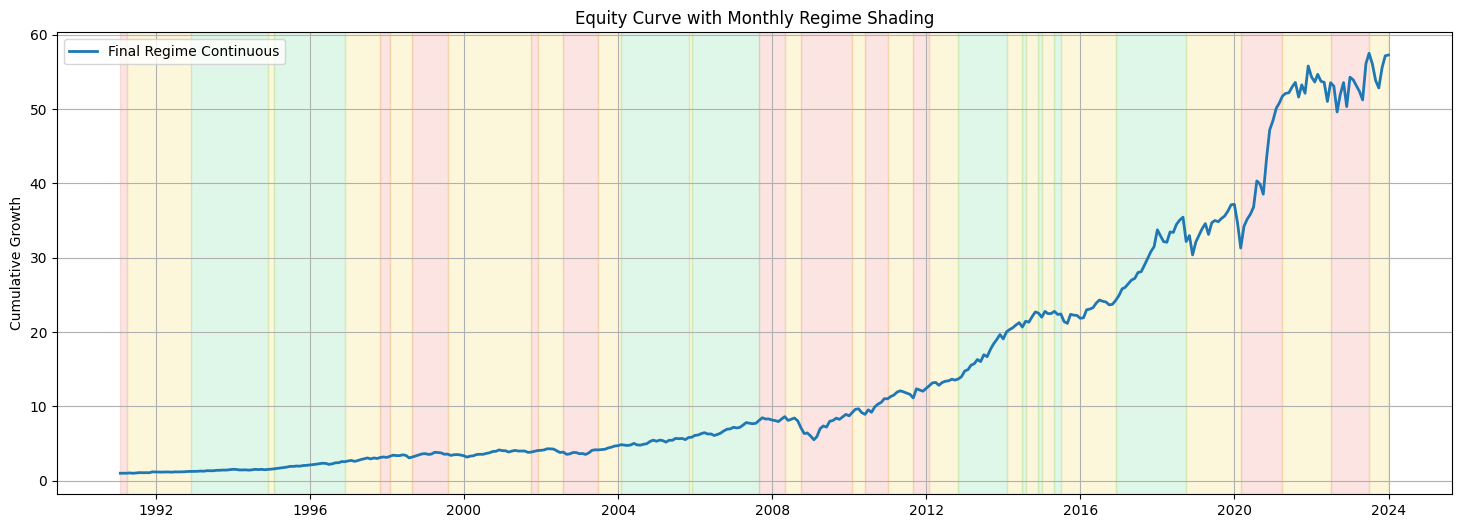

In [ ]:
returns_df_aligned["Final_Regime_Scaled"].describe()

final_continuous_returns = (weights_ts.shift(1) * returns_with_cash).sum(axis=1)

# optional: convert percent to decimal for compounding
final_continuous_returns_dec = final_continuous_returns /100

cum_returns = (1 + final_continuous_returns_dec).cumprod()

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(cum_returns, label="Final Regime Continuous", linewidth=2)

shade_regimes(ax, regime_series)

ax.grid(True)
ax.set_title("Equity Curve with Monthly Regime Shading")
ax.set_ylabel("Cumulative Growth")
ax.legend()


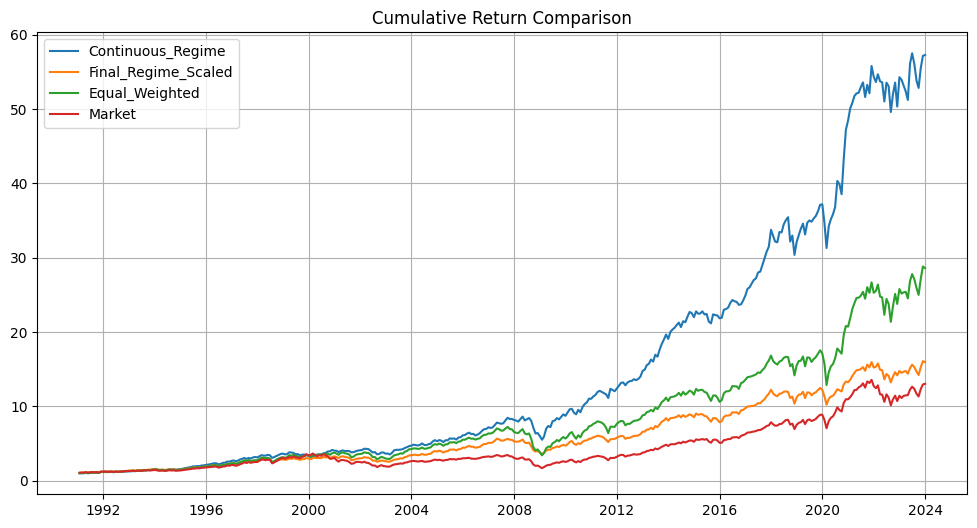

In [ ]:
cum_returns = (1 + returns_df[
    ["Continuous_Regime", "Final_Regime_Scaled", "Equal_Weighted", "Market"]
] / 100).cumprod()

plt.figure(figsize=(12,6))
for col in cum_returns.columns:
    plt.plot(cum_returns[col], label=col)

plt.title("Cumulative Return Comparison")
plt.legend()
plt.grid(True)
plt.show()


####equity curve with shaded regimes for visual understanding

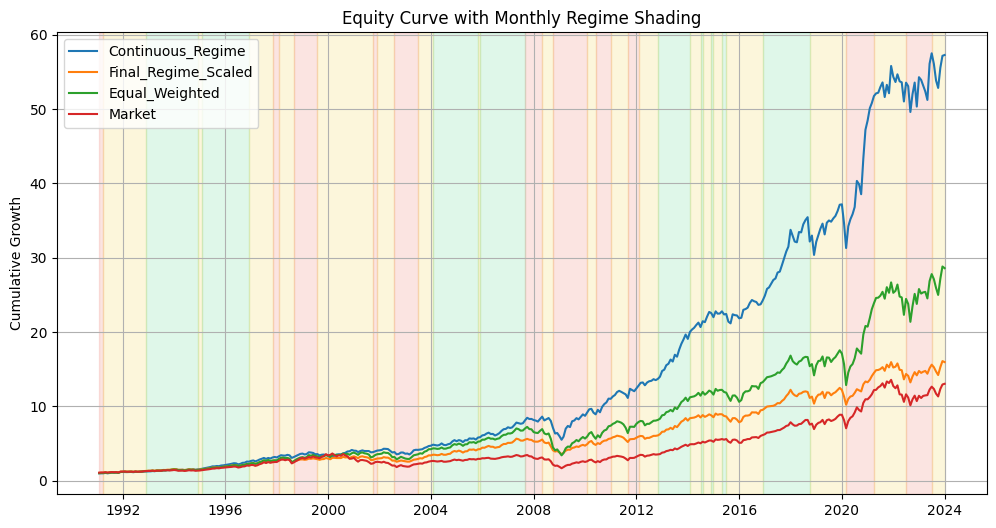

<Figure size 1200x600 with 0 Axes>

In [ ]:
cum_returns = (1 + returns_df[
    ["Continuous_Regime", "Final_Regime_Scaled", "Equal_Weighted", "Market"]
] / 100).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

plt.figure(figsize=(12,6))
for col in cum_returns.columns:
    ax.plot(cum_returns[col], label=col)

shade_regimes(ax, regime_series)

ax.grid(True)
ax.set_title("Equity Curve with Monthly Regime Shading")
ax.set_ylabel("Cumulative Growth")
ax.legend()

In [ ]:
def tail_loss(series, q=0.05):
    return series.quantile(q)

tail_metrics = returns_df[["Final_Regime_Portfolio","Final_Continuous_Regime","Equal_Weighted","Market"]].apply(tail_loss)
print("5% worst-month tail losses:")
print(" ")
print(tail_metrics)


5% worst-month tail losses:
 
Final_Regime_Portfolio    -5.396462
Final_Continuous_Regime   -4.816303
Equal_Weighted            -6.381750
Market                    -7.597500
dtype: float64


####checking risk quality

In [ ]:
def risk_metrics(returns_pct):
    # returns are in % (e.g. 0.7 = 0.7%)

    r = returns_pct / 100  # convert to decimal ONCE

    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1

    return pd.Series({
        "Annual Return (%)": round(ann_ret * 100, 2),
        "Annual Volatility (%)": round(ann_vol * 100, 2),
        "Sharpe": round(sharpe, 2),
        "Max Drawdown (%)": round(dd.min() * 100, 2)
    })

In [ ]:
import numpy as np
import pandas as pd

def risk_metrics(returns_pct):
    # returns are in % (e.g. 0.7 = 0.7%)
    r = returns_pct / 100  # convert to decimal ONCE

    # --- Existing Metrics ---
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1

    # --- NEW: CAGR Calculation ---
    # Formula: (End_Value / Start_Value) ^ (1 / Years) - 1
    total_ret = (1 + r).prod()
    years = len(r) / 12  # Assuming monthly data
    cagr = (total_ret ** (1 / years)) - 1

    return pd.Series({
        "Annual Return (Arith) (%)": round(ann_ret * 100, 2),
        "CAGR (Geo) (%)": round(cagr * 100, 2),  # <--- Added here
        "Annual Volatility (%)": round(ann_vol * 100, 2),
        "Sharpe": round(sharpe, 2),
        "Max Drawdown (%)": round(dd.min() * 100, 2)
    })

In [ ]:
risk_table = returns_df[
    ["Final_Regime_Scaled", "Final_Continuous_Regime","Equal_Weighted", "Market"]
].apply(risk_metrics)

risk_table


,Final_Regime_Scaled,Final_Continuous_Regime,Equal_Weighted,Market
Annual Return (Arith) (%),9.15,13.11,11.48,8.98
CAGR (Geo) (%),8.75,13.05,10.69,8.09
Annual Volatility (%),12.04,12.58,15.90,15.27
Sharpe,0.76,1.04,0.72,0.59
Max Drawdown (%),-36.73,-36.08,-52.96,-54.16


In [ ]:
def regime_risk_table(returns_df, regime_col, portfolio_cols):
    out = {}

    for regime in ["Calm", "Normal", "Stress"]:
        mask = returns_df[regime_col] == regime

        out[regime] = returns_df.loc[mask, portfolio_cols] \
            .apply(risk_metrics)

    return pd.concat(out, axis=1)


In [ ]:
portfolio_cols = [
    "Final_Regime_Scaled",
    "Equal_Weighted",
    "Market",
    "Final_Continuous_Regime"
]

regime_risk = regime_risk_table(
    returns_df,
    regime_col="Final_Regime",
    portfolio_cols=portfolio_cols
)

regime_risk


Calm                        \
                      Final_Regime_Scaled Equal_Weighted Market   
Annual Return (%)                   13.52          13.65  11.61   
Annual Volatility (%)                9.16           8.85   8.36   
Sharpe                               1.48           1.54   1.39   
Max Drawdown (%)                   -11.07         -10.37  -8.90   

                                                           Normal  \
                      Final_Continuous_Regime Final_Regime_Scaled   
Annual Return (%)                       17.47                4.09   
Annual Volatility (%)                    9.13               13.33   
Sharpe                                   1.91                0.31   
Max Drawdown (%)                        -7.11              -28.09   

                                                                     \
                      Equal_Weighted Market Final_Continuous_Regime   
Annual Return (%)               5.01   1.94                    7.53   
Annual Volatility (%)          15.32  15.87                   11.11   
Sharpe                          0.33   0.12                    0.68   
Max Drawdown (%)              -31.08 -52.02                  -21.38   

                                   Stress                        \
                      Final_Regime_Scaled Equal_Weighted Market   
Annual Return (%)                   12.86          21.10  19.08   
Annual Volatility (%)               12.81          23.02  20.45   
Sharpe                               1.00           0.92   0.93   
Max Drawdown (%)                   -26.13         -44.01 -43.00   

                                               
                      Final_Continuous_Regime  
Annual Return (%)                       17.85  
Annual Volatility (%)                   18.14  
Sharpe                                   0.98  
Max Drawdown (%)                       -32.81

left tail focus

In [ ]:
def downside_metrics(returns_pct):
    r = returns_pct / 100

    return pd.Series({
        "5% VaR (%)": round(np.percentile(r, 5) * 100, 2),
        "1% VaR (%)": round(np.percentile(r, 1) * 100, 2),
        "Worst Month (%)": round(r.min() * 100, 2)
    })

def downside_metrics(returns_pct):
    r = returns_pct / 100

    # 1. Calculate Cumulative Wealth Index
    cumulative = (1 + r).cumprod()

    # 2. Calculate the Running Maximum (the peaks)
    peaks = cumulative.cummax()

    # 3. Calculate Drawdown percentage
    drawdowns = cumulative / peaks - 1
    max_drawdown = drawdowns.min() # The largest negative value



    return pd.Series({
        "5% VaR (%)": round(np.percentile(r, 5) * 100, 2),
        "1% VaR (%)": round(np.percentile(r, 1) * 100, 2),

        "Worst Month (%)": round(r.min() * 100, 2),
        "Max Drawdown (%)": round(max_drawdown * 100, 2)
    })


####Stress periods risk features

In [ ]:
stress_mask = returns_df["Final_Regime"] == "Stress"

returns_df.loc[stress_mask, portfolio_cols].apply(downside_metrics)
returns_df[portfolio_cols].apply(downside_metrics)



,Final_Regime_Scaled,Equal_Weighted,Market,Final_Continuous_Regime
5% VaR (%),-5.14,-6.38,-7.60,-4.82
1% VaR (%),-9.62,-11.12,-10.36,-9.26
Worst Month (%),-13.34,-20.43,-17.20,-11.47
Max Drawdown (%),-36.73,-52.96,-54.16,-36.08


regime conditional

In [ ]:
aligned = pd.concat([
    returns_df["Final_Regime_Scaled"],
    df_clean["Final_Regime"],
    df_clean["Total_Exposure"]
], axis=1).dropna()

aligned.columns = ["Returns", "Regime", "Exposure"]

aligned1 = pd.concat([
    returns_df["Final_Continuous_Regime"],
    df_clean["Final_Regime"],
    df_clean["Total_Exposure"]
], axis=1).dropna()

aligned1.columns = ["Returns", "Regime", "Exposure"]

In [ ]:
def regime_conditional_performance(df):
    out = {}

    for regime in ["Calm", "Normal", "Stress"]:
        r = df.loc[df["Regime"] == regime, "Returns"]

        r_dec = r / 100  # % → decimal

        ann_ret = r_dec.mean() * 12
        ann_vol = r_dec.std() * np.sqrt(12)
        sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

        cum = (1 + r_dec).cumprod()
        dd = cum / cum.cummax() - 1

        out[regime] = {
            "Annual Return (%)": round(ann_ret * 100, 2),
            "Annual Volatility (%)": round(ann_vol * 100, 2),
            "Sharpe": round(sharpe, 2),
            "Max Drawdown (%)": round(dd.min() * 100, 2),
            "Avg Exposure": round(df.loc[df["Regime"] == regime, "Exposure"].mean(), 2),
            "Months": len(r)
        }

    return pd.DataFrame(out)



####Discrete Portfolio Statistics

In [ ]:
regime_perf = regime_conditional_performance(aligned)
regime_perf

,Calm,Normal,Stress
Annual Return (%),13.52,4.09,12.86
Annual Volatility (%),9.16,13.33,12.81
Sharpe,1.48,0.31,1.00
Max Drawdown (%),-11.07,-28.09,-26.13
Avg Exposure,0.98,0.86,0.64
Months,129.00,177.00,90.00


####Continuous Portfolio Statistics

In [ ]:
regime_perf1 = regime_conditional_performance(aligned1)
regime_perf1

,Calm,Normal,Stress
Annual Return (%),17.47,7.53,17.85
Annual Volatility (%),9.13,11.11,18.14
Sharpe,1.91,0.68,0.98
Max Drawdown (%),-7.11,-21.38,-32.81
Avg Exposure,0.98,0.86,0.64
Months,129.00,177.00,90.00


transition analysis

In [ ]:
regime_change = df_clean["Final_Regime"] != df_clean["Final_Regime"].shift(1)
transition_dates = df_clean.index[regime_change]


In [ ]:
def transition_event_returns(returns, events, window=3):
    paths = []

    for d in events:
        if d not in returns.index:
            continue
        i = returns.index.get_loc(d)
        if i < window or i + window >= len(returns):
            continue
        paths.append(returns.iloc[i-window:i+window+1].values)

    return np.nanmean(np.vstack(paths), axis=0)


In [ ]:
transition_final = transition_event_returns(
    returns_df["Final_Regime_Scaled"],
    transition_dates
)

transition_ew = transition_event_returns(
    returns_df["Equal_Weighted"],
    transition_dates
)

transition_cont = transition_event_returns(
    returns_df["Final_Continuous_Regime"],
    transition_dates
)


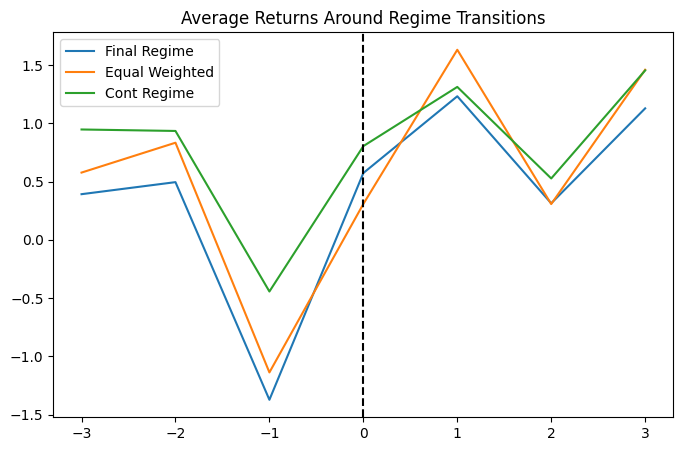

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(-3,4), transition_final, label="Final Regime")
plt.plot(range(-3,4), transition_ew, label="Equal Weighted")
plt.plot(range(-3,4), transition_cont, label="Cont Regime")
plt.axvline(0, linestyle="--", color="black")
plt.title("Average Returns Around Regime Transitions")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def rolling_metrics(returns, window=1):
    """
    Compute rolling annualized metrics:
    - Sharpe (risk-free assumed 0)
    - Volatility
    - Max drawdown
    """
    rolling_mean = returns.rolling(window).mean() * 12  # annualized
    rolling_vol = returns.rolling(window).std() * np.sqrt(12)

    rolling_sharpe = rolling_mean / rolling_vol

    # rolling cumulative returns for drawdown
    rolling_cum = (1 + returns).rolling(window).apply(np.prod, raw=True)
    rolling_dd = rolling_cum / rolling_cum.rolling(window).max() - 1

    return pd.DataFrame({
        "Rolling_Annual_Return": rolling_mean,
        #"Rolling_Annual_Vol": rolling_vol,
        #"Rolling_Sharpe": rolling_sharpe,
        "Rolling_Max_Drawdown": rolling_dd
    })

# Example for final regime portfolio
#final_rolling = rolling_metrics(returns_df["Final_Regime_Portfolio"])
#final_rolling.plot(subplots=True, figsize=(12,10), title="Final Regime Portfolio Rolling Metrics")

#plt.legend()
#plt.show()


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

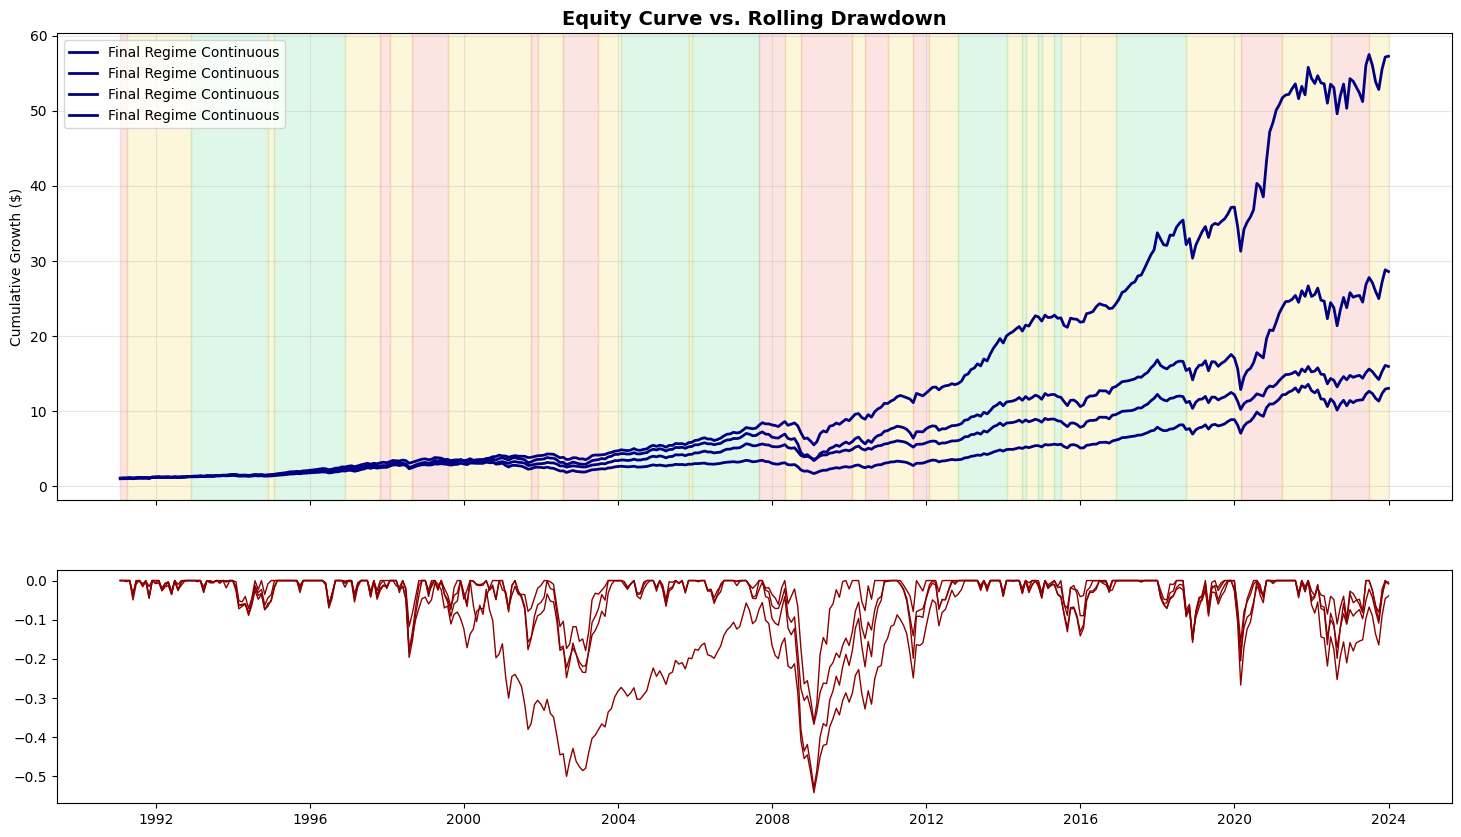

In [ ]:
# --- 1. Calculate Rolling Drawdown ---
# Running Max: The highest point the portfolio has ever reached up to that day
running_max = cum_returns.cummax()

# Drawdown Formula: How far are we from that peak? (e.g., -0.05 means -5%)
drawdown = (cum_returns - running_max) / running_max

# --- 2. Setup the Dual Plot ---
# 2 rows, 1 column. Height ratio 2:1 gives more space to the main equity curve.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})



# --- 3. Top Plot: Equity Curve (Your existing code) ---
ax1.plot(cum_returns, label="Final Regime Continuous", linewidth=2, color='navy')
ax1.set_title("Equity Curve vs. Rolling Drawdown", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Growth ($)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Apply your existing shading function to the top plot
shade_regimes(ax1, regime_series)

# --- 4. Bottom Plot: Rolling Drawdown ---
ax2.plot(drawdown.index, drawdown, label="Drawdown", color='darkred', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3) # Fills the underwater area
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

# Apply your existing shading function to the bottom plot too
# This is crucial: it lets you see if the "Red" shading aligns with the drawdown drops
shade_regimes(ax2, regime_series)

plt.tight_layout()
plt.show()

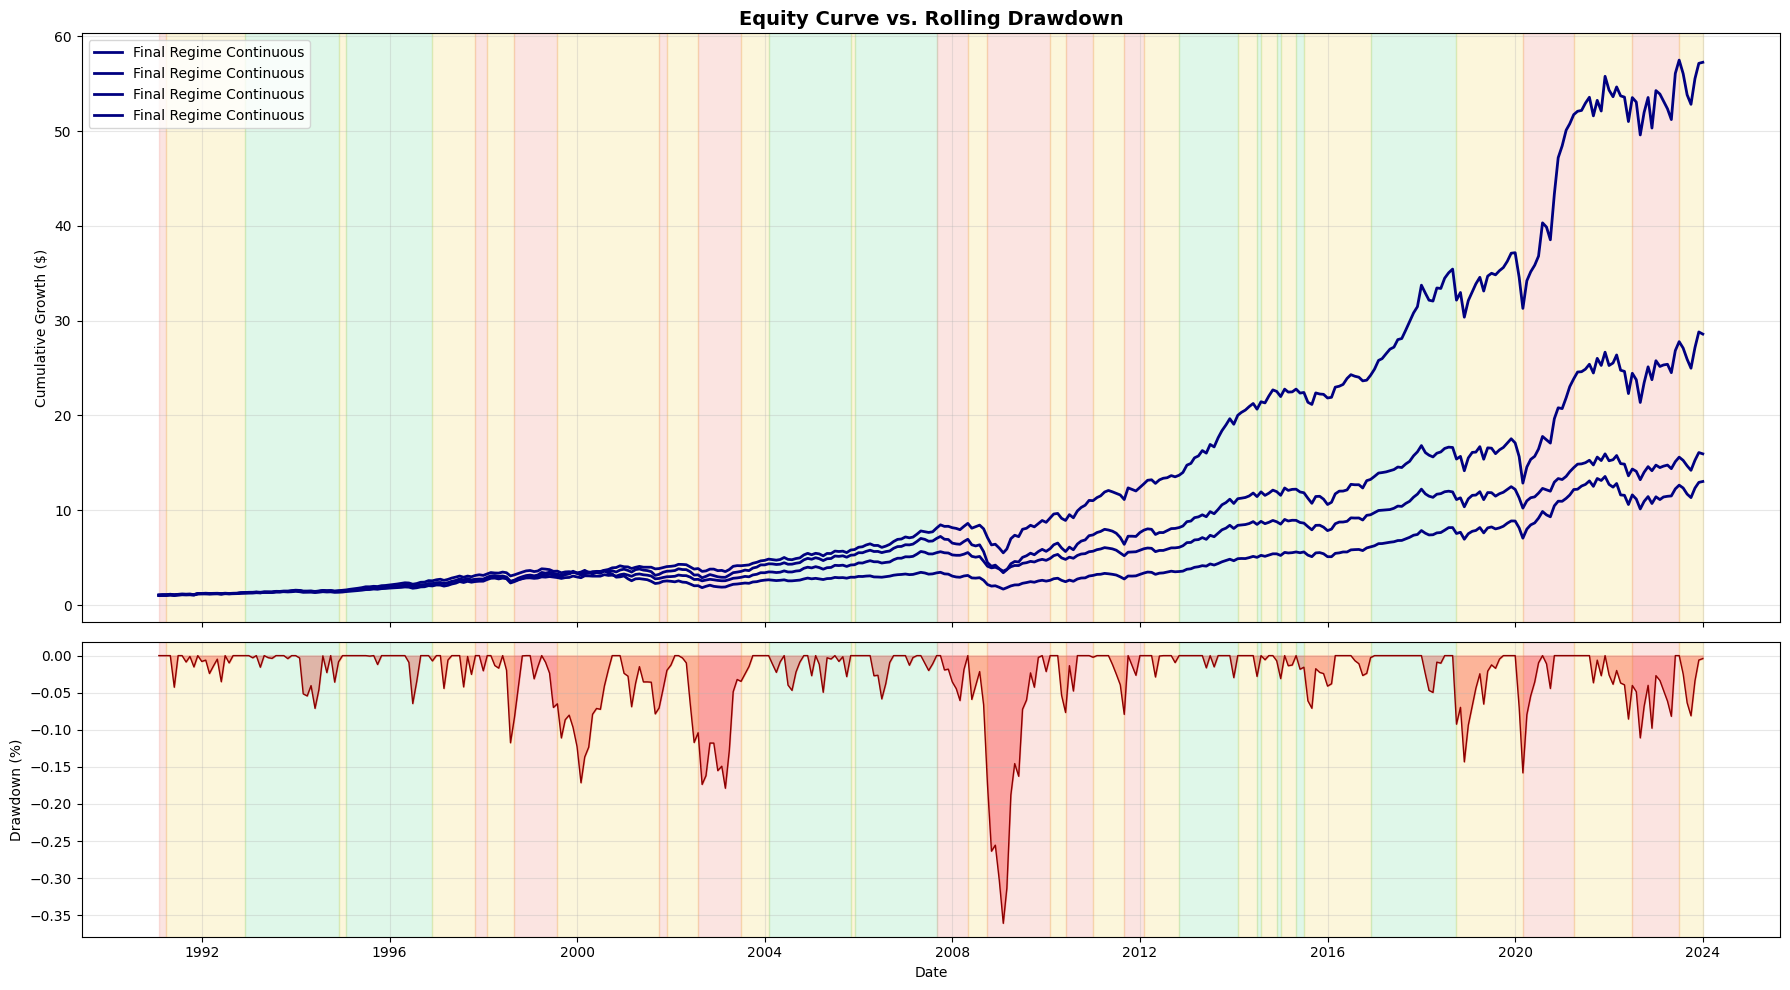

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Data Cleaning & Calculation (Aggressive Fix) ---
# Ensure cum_returns is float
cum_returns_safe = cum_returns.astype(float)

# Calculate Running Max and Drawdown
running_max = cum_returns_safe.cummax()
drawdown = (cum_returns_safe - running_max) / running_max

# FIX: Handle NaNs (force to float first)
drawdown = drawdown.astype(float).fillna(0)

# *** THE KEY FIX ***
# If it is a DataFrame, we explicitly grab the first column to make it a Series.
# If it is already a Series, this block is skipped.
if isinstance(drawdown, pd.DataFrame):
    drawdown = drawdown.iloc[:, 0]

# Extra Safety: If it's a numpy array with shape (N, 1), flatten it
if isinstance(drawdown, np.ndarray) and drawdown.ndim > 1:
    drawdown = pd.Series(drawdown.flatten(), index=cum_returns_safe.index)

# --- 2. Setup the Dual Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# --- 3. Top Plot: Equity Curve ---
ax1.plot(cum_returns_safe.index, cum_returns_safe, label="Final Regime Continuous",
         linewidth=2, color='navy')
ax1.set_title("Equity Curve vs. Rolling Drawdown", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Growth ($)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Apply shading
shade_regimes(ax1, regime_series)

# --- 4. Bottom Plot: Rolling Drawdown ---
# We use .values.flatten() here as a final safety net for plotting
ax2.plot(drawdown.index, drawdown, label="Drawdown", color='darkred', linewidth=1)

ax2.fill_between(drawdown.index, drawdown.values.flatten(), 0, color='red', alpha=0.3)

ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

# Apply shading
shade_regimes(ax2, regime_series)

plt.tight_layout()
plt.show()

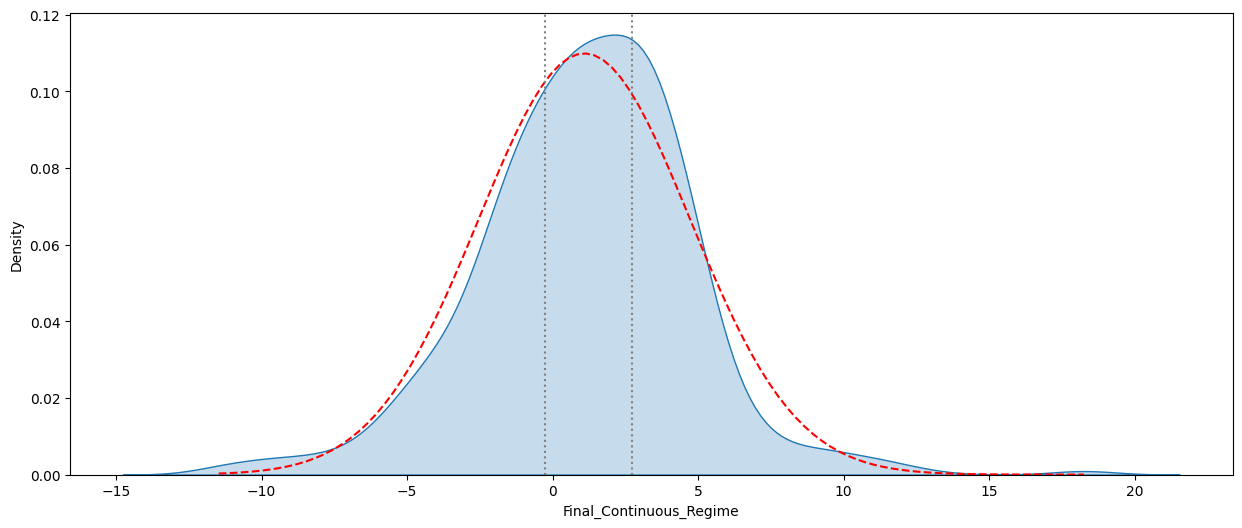

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(15, 6))
# Plot the distribution of your returns
sns.kdeplot(returns_df["Final_Continuous_Regime"], label='Actual Returns (Fat Tails)', fill=True)

# Overlay a Normal Distribution for comparison
mu, std = returns_df["Final_Continuous_Regime"].mean(), returns_df["Final_Continuous_Regime"].std()
x = np.linspace(returns_df["Final_Continuous_Regime"].min(), returns_df["Final_Continuous_Regime"].max(), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r--', label='Normal Distribution (Thin Tails)')

# Draw lines at the 33rd and 66th percentiles to show the "Equal Time" error

plt.axvline(np.percentile(returns_df["Final_Continuous_Regime"], 33), color='gray', linestyle=':')
plt.axvline(np.percentile(returns_df["Final_Continuous_Regime"], 66), color='gray', linestyle=':')

In [ ]:
# 1. Identify the indices where the regime is 'Stress' (assuming Stress = 2)
stress_indices = returns_df[returns_df['Final_Regime'] == "Stress"].index

# 2. Filter the original industry data using those indices
stress_data = df.loc[stress_indices, industry_cols]

# 3. Calculate the matrix
stress_corr_matrix = stress_data.corr()

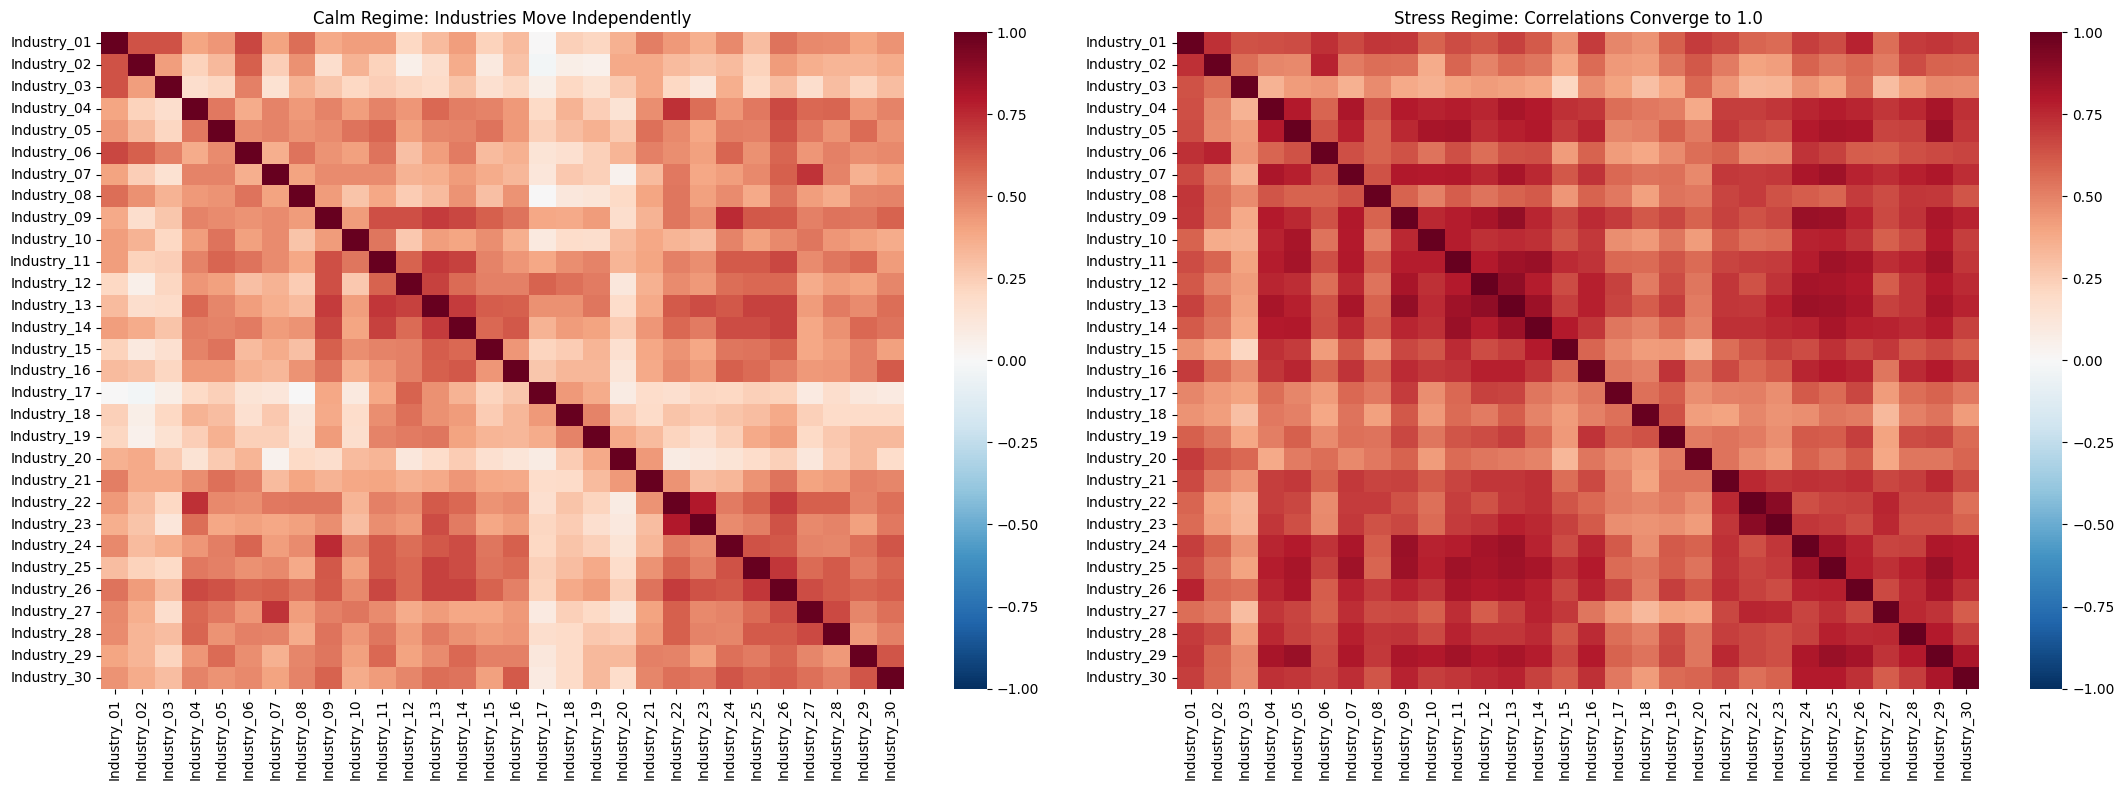

Average Correlation (Calm): 0.41
Average Correlation (Stress): 0.64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter for the "Stress" Regime
stress_indices = returns_df[returns_df['Final_Regime'] == "Stress"].index
stress_corr_matrix = df.loc[stress_indices, industry_cols].corr()

# 2. Filter for the "Calm" Regime
calm_indices = returns_df[returns_df['Final_Regime'] == "Calm"].index
calm_corr_matrix = df.loc[calm_indices, industry_cols].corr()

# 3. Plot them Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Plot Calm Regime
sns.heatmap(calm_corr_matrix, cmap='RdBu_r', center=0, ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Calm Regime: Industries Move Independently')

# Plot Stress Regime
sns.heatmap(stress_corr_matrix, cmap='RdBu_r', center=0, ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Stress Regime: Correlations Converge to 1.0')

plt.tight_layout()
plt.show()

# 4. Calculate Average Correlation for your Report Summary
avg_calm = calm_corr_matrix.values[np.triu_indices_from(calm_corr_matrix, k=1)].mean()
avg_stress = stress_corr_matrix.values[np.triu_indices_from(stress_corr_matrix, k=1)].mean()

print(f"Average Correlation (Calm): {avg_calm:.2f}")
print(f"Average Correlation (Stress): {avg_stress:.2f}")

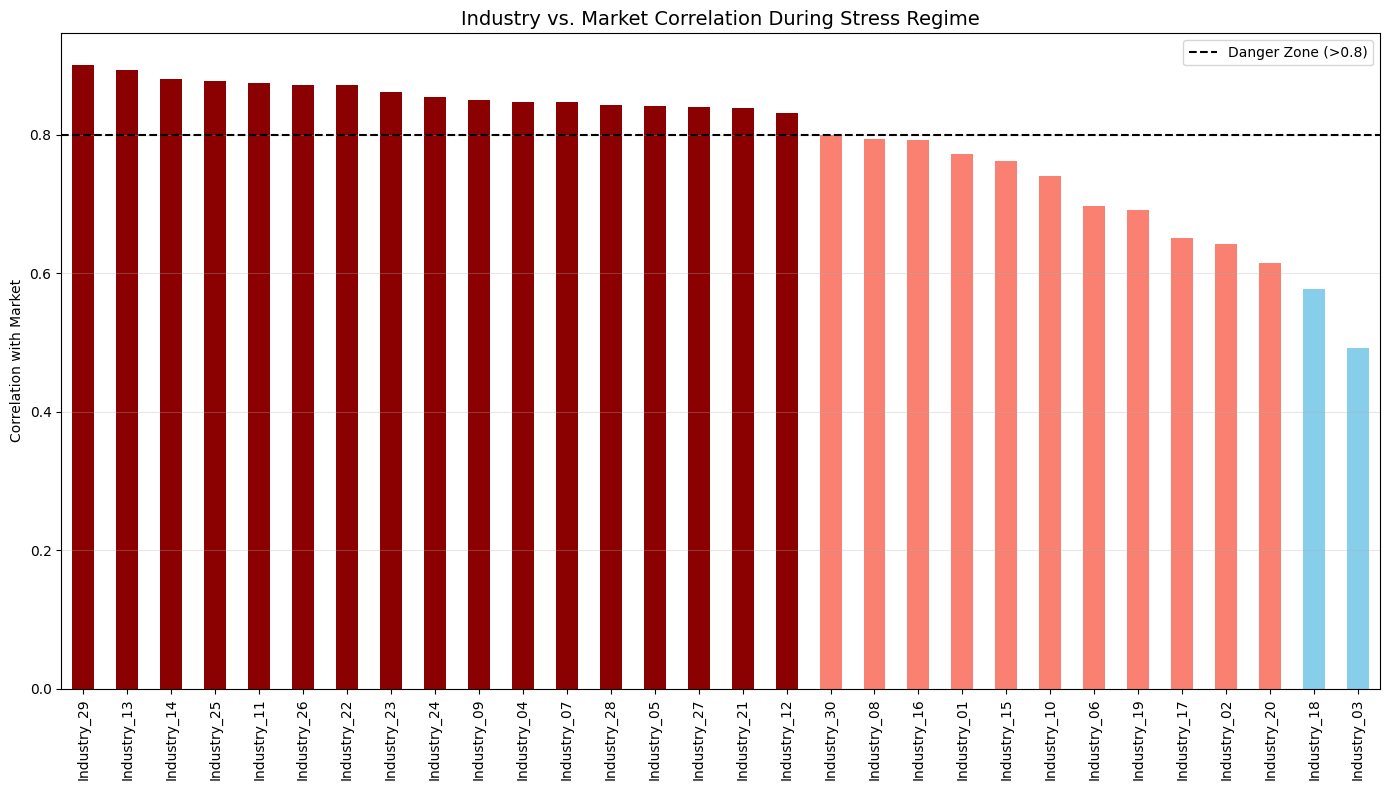

Top 3 Diversifiers (Lowest Correlation):
Industry_20    0.614990
Industry_18    0.576401
Industry_03    0.491498
dtype: float64


In [ ]:
# 1. Filter for Stress Data
stress_data = df.loc[stress_indices]
market_stress = returns_df.loc[stress_indices, "Market"]

# 2. Calculate Correlation of each Industry vs. Market
industry_market_corr = {}

for col in industry_cols:
    # Correlation between specific industry and Market column
    corr = stress_data[col].corr(market_stress)
    industry_market_corr[col] = corr

# 3. Convert to Series and Sort
corr_series = pd.Series(industry_market_corr).sort_values(ascending=False)

# 4. Plot the Ranked Correlations
plt.figure(figsize=(14, 8))
colors = ['darkred' if x > 0.8 else 'salmon' if x > 0.6 else 'skyblue' for x in corr_series.values]

corr_series.plot(kind='bar', color=colors)
plt.axhline(0.8, color='black', linestyle='--', label='Danger Zone (>0.8)')
plt.title('Industry vs. Market Correlation During Stress Regime', fontsize=14)
plt.ylabel('Correlation with Market')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the best diversifiers
print("Top 3 Diversifiers (Lowest Correlation):")
print(corr_series.tail(3))

#DONE